# <CENTER> **PROJECT - E-commerce Cross-Sell Recommendation System**

---

#### **Постановка задачи:**

В данной работе необходимо по имеющимся данным построить рекомендательную систему, которая повысит прибыль от допродаж в интернет-магазине на $20$%

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Провести анализ исходных данных, выявить закономерности между факторами;

* Провести чистку данных от пропущенных значений, дубликатов и выбросов;

* Спроектировать новые признаки с помощью *Feature Engineering* и выявить наиболее значимые при построении модели;

* Обучить модели классического и глубокого обучения, получить значение метрики на валидации;

* Сделать выводы по полученным результатам.

---


#### **Этапы работы над проектом:**

Проект будет состоять из девяти частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Предобработка и очистка данных*;

`3.` *Разведывательный анализ данных (EDA)*;

`4.` *Feature engineering (Генерация факторов, связанных с айтемами)*;

`5.` *Feature engineering (Генерация факторов товар-пользователь)*;

`6.` *Machine Learning*;

`7.` *Оценка и сравнение моделей*;

`8.` *Продвинутая часть*;

`9.` *Общий вывод*.

---

**Импортируем необходимые библиотеки:**

In [ ]:
# Для работы с данными
import numpy as np 
import pandas as pd 
from datetime import datetime
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import random


# Для построения графиков
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns


# Для проведения тестов
from scipy import stats
from statsmodels.stats import proportion
from sklearn.metrics.pairwise import cosine_similarity


import pickle
import torch
import torch.nn as nn

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nИспользуем устройство: {device}')
print('-' * 28)


Используем устройство: cpu
----------------------------


**Загружаем данные:**

In [2]:
# Загружаем датасеты
category_tree_data = pd.read_csv('data/category_tree.csv')
events_data = pd.read_csv('data/events.csv')
item_prop1_data = pd.read_csv('data/item_properties_part1.csv')
item_prop2_data = pd.read_csv('data/item_properties_part2.csv')

=============================================================================================================================================

## <center> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

**Выведем информацию по таблицам.**

Создаём функцию:

In [3]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'\nДанные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data)
    print('-' * length2)

Выводим результат:

In [4]:
# Создаём список таблиц
data_list = [
    category_tree_data,
    events_data,
    item_prop1_data,
    item_prop2_data
]

# Создаём список названий таблиц
data_name_list = [
    'category_tree_data',
    'events_data',
    'item_prop1_data',
    'item_prop2_data'
]




# Пройдёмся циклом 'for' по созданным спискам, и для каждого значения построим таблицу
for df, name in zip(data_list, data_name_list):
    
    # Выводим информацию по полученной таблице 'df'              
    check_data_inf(
        data = df,
        data_name = name,
        length1 = 40,
        length2 = 70
    )
    print('\n\n')


Данные таблицы "category_tree_data" имеют следующую размерность:

Количество строк: 1669;
Количество признаков (столбцов): 2.
----------------------------------------


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
...,...,...
1664,49,1125.0
1665,1112,630.0
1666,1336,745.0
1667,689,207.0


----------------------------------------------------------------------




Данные таблицы "events_data" имеют следующую размерность:

Количество строк: 2756101;
Количество признаков (столбцов): 5.
----------------------------------------


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


----------------------------------------------------------------------




Данные таблицы "item_prop1_data" имеют следующую размерность:

Количество строк: 10999999;
Количество признаков (столбцов): 4.
----------------------------------------


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513
...,...,...,...,...
10999994,1439694000000,86599,categoryid,618
10999995,1435460400000,153032,1066,n1020.000 424566
10999996,1440298800000,421788,888,35975 856003 37346
10999997,1437879600000,159792,400,n552.000 639502 n720.000 424566


----------------------------------------------------------------------




Данные таблицы "item_prop2_data" имеют следующую размерность:

Количество строк: 9275903;
Количество признаков (столбцов): 4.
----------------------------------------


,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062
...,...,...,...,...
9275898,1433646000000,236931,929,n12.000
9275899,1440903600000,455746,6,150169 639134
9275900,1439694000000,347565,686,610834
9275901,1433646000000,287231,867,769062


----------------------------------------------------------------------





#### **Основные характеристики:**

**events — датасет с событиями. Колонки:**

* `timestamp` — время события;

* `visitorid` — идентификатор пользователя;

* `event` — тип события;

* `itemid` — идентификатор объекта;

* `transactionid` — идентификатор транзакции, если она проходила.

--

**category_tree — файл с деревом категорий (можно восстановить дерево).**

* `category_id` — идентификатор категорий;

* `parent_id` — идентификатор родительской категории.

--

**item_properties — файл с свойствами товаров.**

* `timestamp` — момент записи значения свойства;

* `item_id` — идентификатор объекта;

* `property` — свойство, кажется, они все, кроме категории, захешированы;

* `value` — значение свойства.

---

#### $1.2$

Выведем информацию по признакам:

In [5]:
# Пройдёмся циклом 'for' по созданным спискам, и по каждой таблице выведем информацию
for df, name, in zip(data_list, data_name_list):
    
    # Вывод информации
    print('\n')
    print('-' * 72)
    print(f'==============| Информация датасета "{name}" |==============')
    print('-' * 72)
    print('\n')
    
    display(df.info())
    print('-' * 72)
    print('\n\n')



------------------------------------------------------------------------
==============| Информация датасета "category_tree_data" |==============
------------------------------------------------------------------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


None

------------------------------------------------------------------------





------------------------------------------------------------------------
==============| Информация датасета "events_data" |==============
------------------------------------------------------------------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None

------------------------------------------------------------------------





------------------------------------------------------------------------
==============| Информация датасета "item_prop1_data" |==============
------------------------------------------------------------------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 335.7+ MB


None

------------------------------------------------------------------------





------------------------------------------------------------------------
==============| Информация датасета "item_prop2_data" |==============
------------------------------------------------------------------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275903 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 283.1+ MB


None

------------------------------------------------------------------------





#### $1.3$

#### **Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [6]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    '''       
    
    Функция для подсчёта количества признаков по типам данных в каждой таблице.
    
    На вход функции передаётся:
        - data - таблица, для которой необходимо рассчитать количество признаков по типам данных;
        - data_name - название таблицы, для которой необходимо рассчитать количество признаков по типам данных;
        - length1 - длина разделителя для заголовка;
        - length2 - длина разделителя для результата.
    
    '''
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'\nВ таблице "{data_name}" представлены признаки следующих типов:')
    print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [7]:
# Пройдёмся циклом 'for' по созданным спискам, и по каждой таблице выведем информацию
for df, name in zip(data_list, data_name_list):
    
    # Вывод информации
    check_features_dtypes(
        data = df,
        data_name = name,
        length1 = 70,
        length2 = 45
    )
    print('\n\n')


В таблице "category_tree_data" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 1
Количество признаков типа 'float64': 1
Количество признаков типа 'bool': 0
---------------------------------------------




В таблице "events_data" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 1
Количество признаков типа 'int64': 3
Количество признаков типа 'float64': 1
Количество признаков типа 'bool': 0
---------------------------------------------




В таблице "item_prop1_data" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 2
Количество признаков типа 'int64': 2
Количество признаков типа 'float64': 0
Количество признаков типа 'bool': 0
---------------------------------

#### $1.4$

Выведем описательные характеристики по признакам:

In [8]:
# Пройдёмся циклом 'for' по созданным спискам, и по каждой таблице выведем информацию
for df, name in zip(data_list, data_name_list):
    
    # Вывод информации
    print(f'\nОписательные характеристики датасета "{name}":\n')
    display(df.describe())
    print('-' * 70)
    print('\n\n')


Описательные характеристики датасета "category_tree_data":



,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000


----------------------------------------------------------------------




Описательные характеристики датасета "events_data":



,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


----------------------------------------------------------------------




Описательные характеристики датасета "item_prop1_data":



,timestamp,itemid
count,1.100000e+07,1.100000e+07
mean,1.435158e+12,2.333851e+05
std,3.327653e+09,1.348258e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165150e+05
50%,1.433646e+12,2.334990e+05
75%,1.437880e+12,3.501860e+05
max,1.442113e+12,4.668660e+05


----------------------------------------------------------------------




Описательные характеристики датасета "item_prop2_data":



,timestamp,itemid
count,9.275903e+06,9.275903e+06
mean,1.435156e+12,2.333968e+05
std,3.327970e+09,1.348682e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165175e+05
50%,1.433646e+12,2.334620e+05
75%,1.437880e+12,3.504470e+05
max,1.442113e+12,4.668660e+05


----------------------------------------------------------------------





#### $1.5$

#### **Объединение всех таблиц в одну.**

**Объединение `item_prop1_data` и `item_prop2_data`:**

Обе таблицы имеют одинаковую структуру: `timestamp`, `itemid`, `property`, `value`. Мы объединим их в одну таблицу и выберем самые последние значения свойств для каждого `itemid` и `property`, чтобы избежать дублирования:

In [9]:
# Объединение таблиц
item_properties = pd.concat(
    [item_prop1_data, item_prop2_data],
    ignore_index = True
)

# Сортировка по времени для выбора самых последних значений
item_properties = item_properties.sort_values(by = ['itemid', 'property', 'timestamp'])

# Выбор последнего значения для каждой пары itemid-property
item_properties = item_properties.groupby(['itemid', 'property']).last().reset_index()

# Сохранение только нужных столбцов
item_properties = item_properties[['itemid', 'property', 'value', 'timestamp']]




# Выведем результат
check_data_inf(
    data = item_properties,
    data_name = 'item_properties',
    length1 = 40,
    length2 = 70
)


Данные таблицы "item_properties" имеют следующую размерность:

Количество строк: 12003814;
Количество признаков (столбцов): 4.
----------------------------------------


,itemid,property,value,timestamp
0,0,1036,1276750,1433646000000
1,0,1056,n3.168 1144008,1433041200000
2,0,11,n15360.000 628176 n12288.000,1433646000000
3,0,112,679677,1433646000000
4,0,127,1168476,1433041200000
...,...,...,...,...
12003809,466866,888,892415 670753 114844 808585,1431226800000
12003810,466866,896,769062,1433041200000
12003811,466866,917,89667,1431226800000
12003812,466866,available,0,1432436400000


----------------------------------------------------------------------


**Извлечение `categoryid` из `item_properties`:**

Для рекомендаций наиболее важным свойством является `categoryid`. Мы отфильтруем строки, где `property == 'categoryid'`, чтобы получить категории товаров:

In [10]:
# Фильтрация только 'categoryid'
item_categories = item_properties[item_properties['property'] == 'categoryid'][['itemid', 'value']]

# Переименование столбца 'value' в 'categoryid'
item_categories = item_categories.rename(columns = {'value': 'categoryid'})

# Преобразование categoryid в числовой формат 
item_categories['categoryid'] = item_categories['categoryid'].astype(int)




# Выведем результат
check_data_inf(
    data = item_categories,
    data_name = 'item_categories',
    length1 = 40,
    length2 = 40
)


Данные таблицы "item_categories" имеют следующую размерность:

Количество строк: 417053;
Количество признаков (столбцов): 2.
----------------------------------------


,itemid,categoryid
27,0,209
62,1,1114
86,2,1305
115,3,1171
140,4,1038
...,...,...
12003693,466862,1376
12003716,466863,173
12003744,466864,373
12003771,466865,421


----------------------------------------


**Обогащение таблицы `events` категориями:**

Теперь добавим информацию о категориях к таблице `events` через объединение по `itemid`:

In [11]:
# Объединение `events_data` с `item_categories`
events_with_categories = events_data.merge(
    item_categories[['itemid', 'categoryid']],
    on = 'itemid',
    how = 'left'
)




# Выведем результат
check_data_inf(
    data = events_with_categories,
    data_name = 'events_with_categories',
    length1 = 40,
    length2 = 75
)


Данные таблицы "events_with_categories" имеют следующую размерность:

Количество строк: 2756101;
Количество признаков (столбцов): 6.
----------------------------------------


,timestamp,visitorid,event,itemid,transactionid,categoryid
0,1433221332117,257597,view,355908,NaN,1173.0
1,1433224214164,992329,view,248676,NaN,1231.0
2,1433221999827,111016,view,318965,NaN,NaN
3,1433221955914,483717,view,253185,NaN,914.0
4,1433221337106,951259,view,367447,NaN,491.0
...,...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN,1623.0
2756097,1438399813142,762376,view,115946,NaN,1616.0
2756098,1438397820527,1251746,view,78144,NaN,969.0
2756099,1438398530703,1184451,view,283392,NaN,1589.0


---------------------------------------------------------------------------


**Добавление иерархии категорий из `category_tree`:**

Теперь присоединим информацию о родительских категориях из `category_tree`, чтобы учесть иерархию.

In [12]:
# Объединение 'events_with_categories' с 'category_tree'
events_with_hierarchy = events_with_categories.merge(
    category_tree_data[['categoryid', 'parentid']],
    on = 'categoryid',
    how = 'left'
)




# Выведем результат
check_data_inf(
    data = events_with_hierarchy,
    data_name = 'events_with_hierarchy',
    length1 = 40,
    length2 = 85
)


Данные таблицы "events_with_hierarchy" имеют следующую размерность:

Количество строк: 2756101;
Количество признаков (столбцов): 7.
----------------------------------------


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid
0,1433221332117,257597,view,355908,NaN,1173.0,805.0
1,1433224214164,992329,view,248676,NaN,1231.0,901.0
2,1433221999827,111016,view,318965,NaN,NaN,NaN
3,1433221955914,483717,view,253185,NaN,914.0,226.0
4,1433221337106,951259,view,367447,NaN,491.0,679.0
...,...,...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN,1623.0,1066.0
2756097,1438399813142,762376,view,115946,NaN,1616.0,827.0
2756098,1438397820527,1251746,view,78144,NaN,969.0,1141.0
2756099,1438398530703,1184451,view,283392,NaN,1589.0,1426.0


-------------------------------------------------------------------------------------


**Фильтрация релевантных данных:**

Для рекомендательной системы нас интересуют:

  * События типа `view` и `transaction`, так как они отражают интересы пользователей и их покупки,
  * Товары с известными категориями,
  * Транзакции для анализа продаж и популярности товаров:

In [13]:
# Фильтрация событий 'view' и 'transaction'
events_filtered = events_with_hierarchy[
    events_with_hierarchy['event'].isin(['view', 'transaction'])
]

# Удалим строки, где 'categoryid' отсутствует
events_filtered = events_filtered.dropna(subset = ['categoryid'])




# Выведем результат
check_data_inf(
    data = events_filtered,
    data_name = 'events_filtered',
    length1 = 40,
    length2 = 85
)


Данные таблицы "events_filtered" имеют следующую размерность:

Количество строк: 2432017;
Количество признаков (столбцов): 7.
----------------------------------------


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid
0,1433221332117,257597,view,355908,NaN,1173.0,805.0
1,1433224214164,992329,view,248676,NaN,1231.0,901.0
3,1433221955914,483717,view,253185,NaN,914.0,226.0
4,1433221337106,951259,view,367447,NaN,491.0,679.0
5,1433224086234,972639,view,22556,NaN,1074.0,339.0
...,...,...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN,1623.0,1066.0
2756097,1438399813142,762376,view,115946,NaN,1616.0,827.0
2756098,1438397820527,1251746,view,78144,NaN,969.0,1141.0
2756099,1438398530703,1184451,view,283392,NaN,1589.0,1426.0


-------------------------------------------------------------------------------------


=============================================================================================================================================

## <center> **`2.` Предобработка и очистка данных**

На данном этапе выявим и очистим данные от пропусков, дубликатов и выбросов.

#### $2.1$

**Проверим данные на наличие пропусков.**

Создаём $2$ функции для рассчёта пропусков и построения тепловой карты:

In [14]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('\nСуммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)





# Построим тепловую карту пропусков
# Создаём функцию отображения пропущенных значений на тепловой карте
def missing_values_heatmap(data):
    
    # Рассчитываем количество пропусков
    cols_null_persent = data.isnull().mean() * 100
    cols_with_null = cols_null_persent[cols_null_persent > 0].sort_values(ascending = False)
    print(f'Информация по количествам пропусков в процентах:\n\n{cols_with_null}')
    print('-' * 50)
    
    # Задаём параметры графика
    colors = sns.color_palette('coolwarm')
    fig = plt.figure(figsize = (30, 15))
    cols = cols_with_null.index
    
    # Строим тепловую карту
    ax = sns.heatmap(
        data = data[cols].isnull(),
        cmap = sns.color_palette(colors)
    )
    
    # Задаём название графика
    plt.title('Тепловая карта пропущенных значений', fontsize = 20)
    
    # Выводим график
    plt.show()
    print('-' * 110)
    
    return ax

Выводим результаты выборки:


Суммарное количество пропусков в таблице "events_filtered": 2410042 

Информация по количествам пропусков: 

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2410035
categoryid             0
parentid               7
dtype: int64 

--------------------------------------------------


Информация по количествам пропусков в процентах:

transactionid    99.096141
parentid          0.000288
dtype: float64
--------------------------------------------------


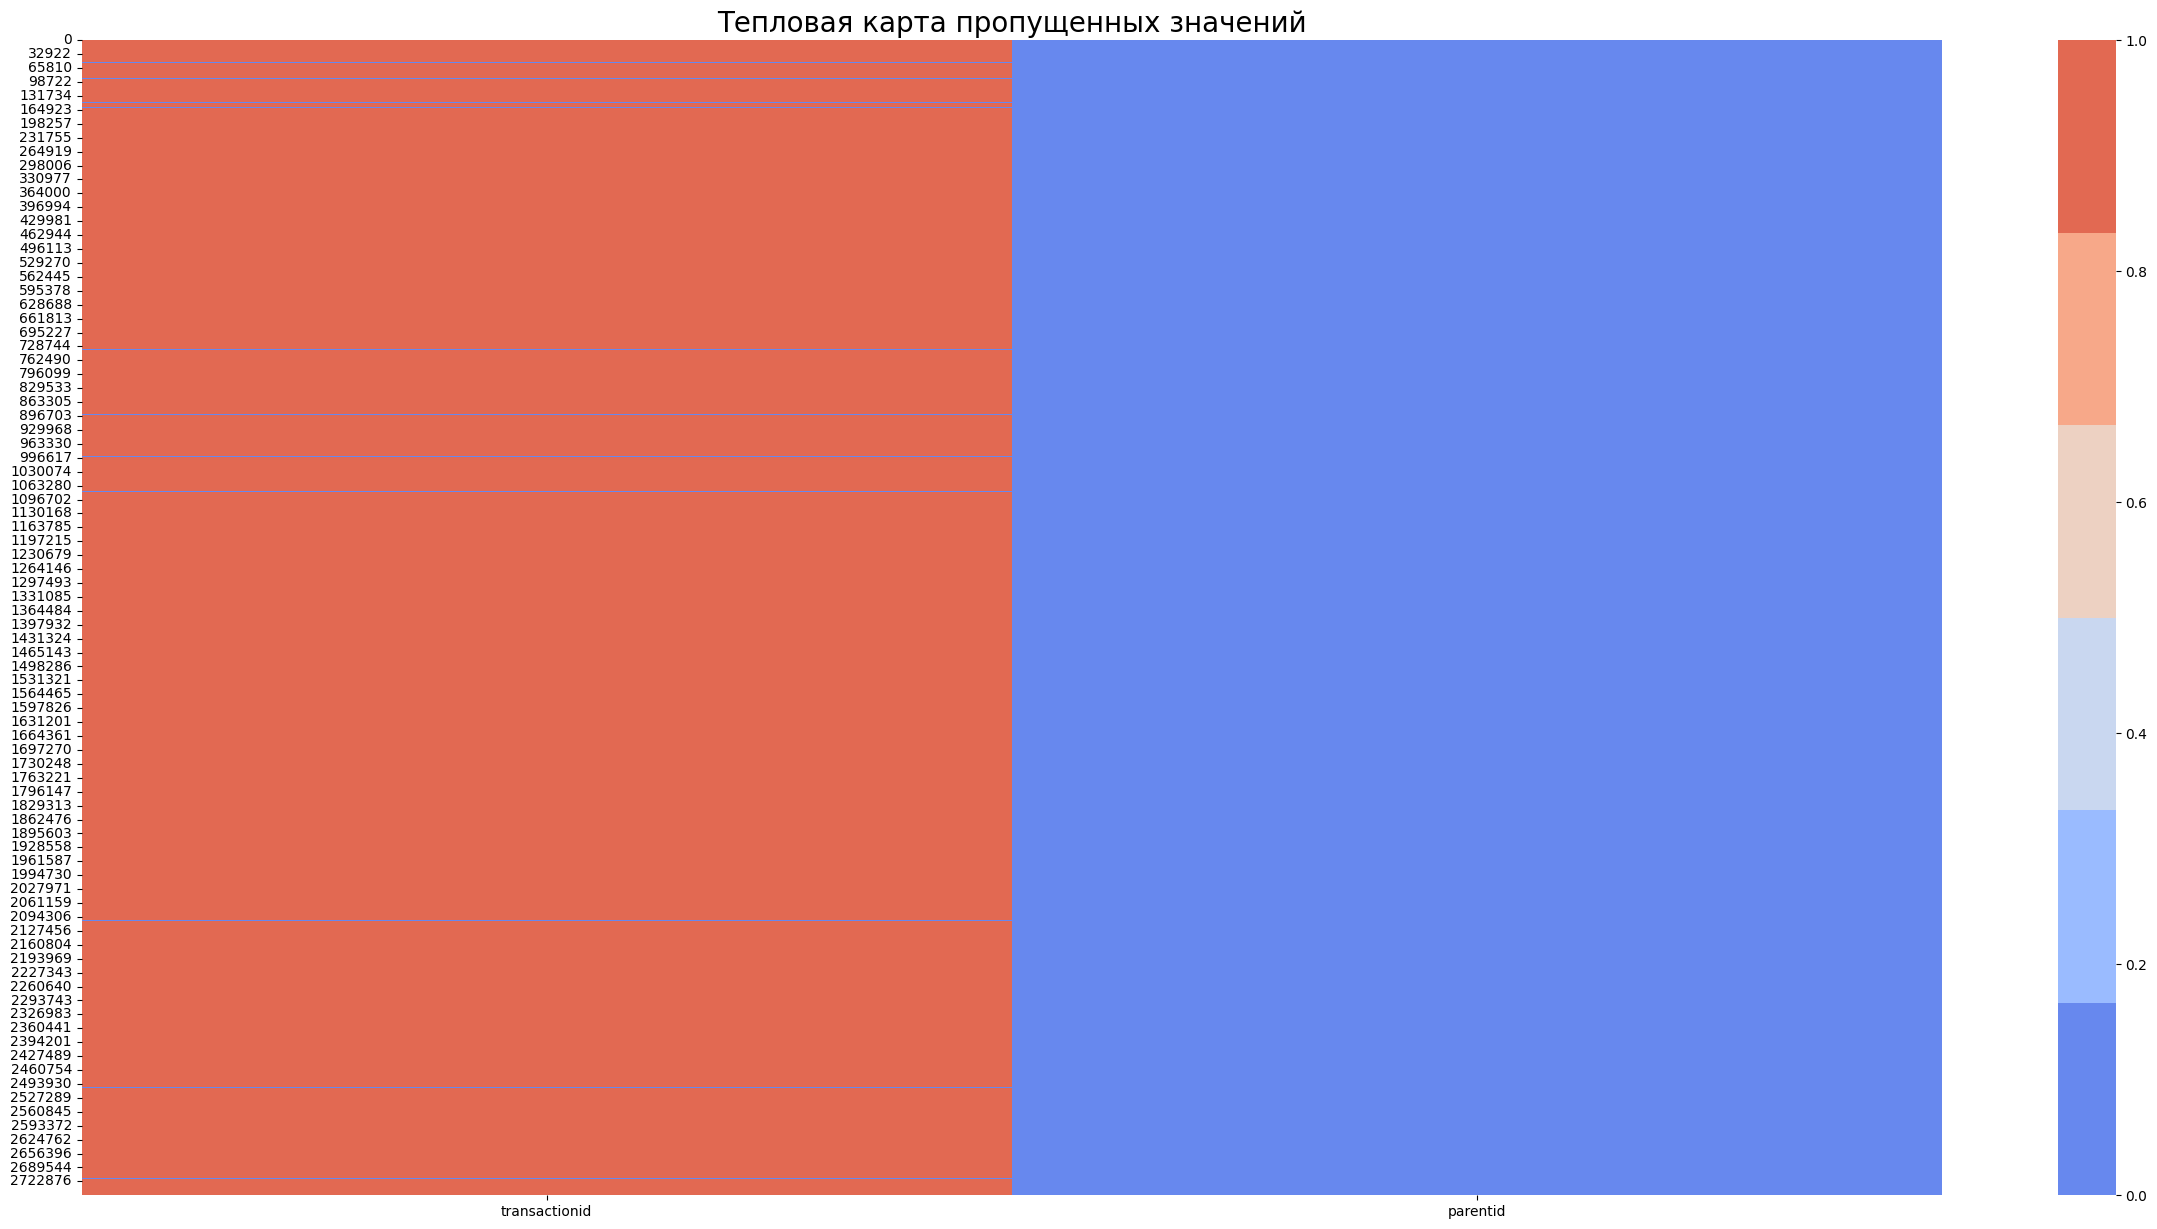

--------------------------------------------------------------------------------------------------------------


<Axes: title={'center': 'Тепловая карта пропущенных значений'}>

In [15]:
# Выводим количество пропусков
missing_values_count(
    data = events_filtered,
    data_name = 'events_filtered',
    length = 50
)
print('\n')



# Выводим тепловую карту
missing_values_heatmap(data = events_filtered)

**Вывод:**

**`transactionid`:**

Высокий процент пропусков в `transactionid` ожидаем, так как этот столбец заполняется только для событий типа `transaction`, которые составляют малую долю всех событий (в основном `view`). Пропуски в данном признаке не требуют заполнения, так как они естественны — отсутствие `transactionid` означает, что событие не связано с покупкой.

**`parentid`:**

Процент пропусков ($0.000288$%) очень низкий, что делает их влияние минимальным. Заполним пропуски значением $0$, интерпретируя это как отсутствие родительской категории (например, категория является корневой).

Заполним пропуски в признаке `parentid`:

In [16]:
# Заполняем пропуски
events_filtered['parentid'] = events_filtered['parentid'].fillna(0)

# Выводим количество пропусков в признаке после заполнения 0
print('\nКоличество пропущенных значений в признаке "parentid": {}'.format(events_filtered['parentid'].isna().sum()))


Количество пропущенных значений в признаке "parentid": 0


#### $2.2$

**Проверяем данные на наличие дубликатов:**

In [17]:
# Создаём список признаков
dupl_columns = list(events_filtered.columns)


# Создаём маску дубликатов с помощью метода duplicated() и произведём фильтрацию
mask = events_filtered.duplicated(subset = dupl_columns)
events_duplicates = events_filtered[mask]
print(f'\nЧисло найденных дубликатов: {events_duplicates.shape[0]}')
print('-' * 40)


Число найденных дубликатов: 85
----------------------------------------


В данных содержится $85$ дублирующихся значений. Для продолжения анализа и обученя модели необходимо произвести чистку от дубликатов.

Удалим найденные дубликаты:

In [18]:
# Удаляем дубликаты
events_filtered = events_filtered.drop_duplicates(subset = dupl_columns)
print(f'\nРезультирующее число записей: {events_filtered.shape[0]}')
print('-' * 40)


# Вычеслим оставшееся количество дубликатов
mask = events_filtered.duplicated(subset = dupl_columns)
events_duplicates = events_filtered[mask]
print(f'\nКоличество дубликатов после обработки: {events_duplicates.shape[0]}')
print('-' * 40)


Результирующее число записей: 2431932
----------------------------------------

Количество дубликатов после обработки: 0
----------------------------------------


#### $2.3$

**Проверяем данные на наличие выбросов.**

Создадим список признаков с возможными выбросами:

In [19]:
# Создание списка признаков типа 'int64' и 'float64'
numeric_columns = events_filtered.select_dtypes(include = ['int32', 'int64', 'float64']).columns.tolist()

Создадим функцию для поиска выбросов:

In [20]:
# Функция для поиска выбросов через IQR
def detect_outliers_iqr(data, features):
    
    
    '''      
    Функция поиска выбросов через IQR.
    
    Параметры:
        - data: данные,
        - features: признаки
    
    Возвращает:
        - Словарь с выбросами.
    '''
    
    
    # Создаём словарь, ключами которого будут индексы признаков,
    # а значениями - их количество
    outliers_dict = {}
    
    
    # Пройдёмся циклом for по признакам
    for feature in features:
        
        Q1 = data[feature].quantile(0.25)         # первый квартиль
        Q3 = data[feature].quantile(0.75)         # третий квартиль
        IQR = Q3 - Q1                             # межквартильный размах
        
        # Границы (нижняя и верхняя) для определения выбросов
        lower_bound = Q1 - 1.5 * IQR    
        upper_bound = Q3 + 1.5 * IQR   
        
        # Поиск выбросов
        outliers_dict[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]  
    
    
    # Возвращаем результат  
    return outliers_dict

Организуем поиск выбросов:

In [21]:
# Создаём переменную, в котором будем хранить признаки с количеством выбросов
outliers = detect_outliers_iqr(
    data = events_filtered,
    features = numeric_columns
)




# Создаём заглавие
print('\nИнформация по выбросам в данных:')
print('-' * 35)
print('\n\n\n')

# Вывод выбросов
for feature, values in outliers.items():
    if len(values) > 0:
        print('Признак: "{}"'.format(feature))
        print('Количество выбросов: {}'.format(len(values)))
        print('-' * 70)
        print()


Информация по выбросам в данных:
-----------------------------------






=============================================================================================================================================

## <center> **`3.` Разведывательный анализ данных (EDA)**

На данном этапе проведём небольшой анализ данных и построим несколько визуализаций.

#### $3.1$

Подсчитаем, какой процент продаж обеспечивают топовые товары $($точка отсечения — $1$ июля$)$:

In [22]:
# Точка отсечения: 1 июля 2015
cutoff_date = int(datetime(2015, 7, 1).timestamp() * 1000)


# Фильтрация транзакций до 1 июля
transactions_data = events_filtered[
    (events_filtered['event'] == 'transaction') &
    (events_filtered['timestamp'] < cutoff_date)
]


# Подсчёт транзакций по товарам
item_transactions = transactions_data.groupby('itemid').size().reset_index(name = 'transaction_count')


# Вычисляем топ-3 товара
top_3_items = item_transactions.sort_values(
    by = 'transaction_count',
    ascending = False
).head(3)


# Общее количество транзакций
total_transactions = len(transactions_data)


# Количество транзакций для топ-3
top_3_transactions = top_3_items['transaction_count'].sum()


# Процент продаж
percentage = (top_3_transactions / total_transactions) * 100
print(f'\nПроцент продаж от топ-3 товаров: {percentage:.2f}%')
print('-' * 40)


Процент продаж от топ-3 товаров: 1.02%
----------------------------------------


#### $3.2$

**Формулировка статистических гипотез и подбор статистического теста для их проверки.**

Сформулируем статистические гипотезы и выберем подходящие тесты для анализа данных в соответствии с поставленными бизнес-вопросами:

1. Есть ли значимые различия в поведении пользователей, товарах или категориях?
2. Выявить закономерности, которые могут повлиять на рекомендации,
3. Подтвердить гипотезы, связанные с допродажами для увеличения прибыли на $20$%.

---

##### **1. Сравнение конверсии между топ-категорией и остальными**

* **Статистические гипотезы:**

    * $H_0$: Конверсия (доля транзакций от просмотров) в топ-категории равна конверсии в остальных категориях;

    * $​H_1$: Конверсия в топ-категории выше.

* **Выбор теста:**

Поскольку мы сравниваем пропорции (конверсии) между двумя независимыми группами, используем **$Z$-тест для пропорций**.

* **Проверка нормальности:**

Для $Z$-теста нормальность не требуется, так как он основан на асимптотическом приближении и работает с большими выборками.

---

##### **2. Сравнение активности пользователей**

* **Статистические гипотезы:**

    * $H_0$: Среднее количество просмотров на пользователя в топ-категории равно среднему в остальных категориях;

    * $H_1$: Среднее количество просмотров в топ-категории выше.

* **Выбор теста:**

Мы могли бы сравнить среднее количество просмотров между категориями с помощью **t-теста** или **U-теста Манна-Уитни** (в зависимости от нормальности).

* **Проверка нормальности:**

Такие данные можно проверить на нормальность с помощью **теста Шапиро-Уилка** или визуально (**гистограмма/Q-Q plot**).

---

##### **3. Зависимость события от категории**

* **Статистические гипотезы:**

    * $H_0$: Тип события (`view` или `transaction`) не зависит от `categoryid`;

    * $H_1$: Тип события зависит от категории.

* **Выбор теста:**

На данном этапе воспользуемся тестом **Хи-квадрат**.

---

#### $3.3$

##### **Сравнение конверсии между топ-категорией и остальными.**

Используем **$Z$-тест для пропорций**:

In [23]:
# Определяем топ-категорию по транзакциям
transactions_data = events_filtered[events_filtered['event'] == 'transaction']
views_data = events_filtered[events_filtered['event'] == 'view']
top_category = transactions_data.groupby('categoryid').size().idxmax()

# Фильтрация данных для топ-категории и остальных
top_cat_data = events_filtered[events_filtered['categoryid'] == top_category]
other_cat_data = events_filtered[events_filtered['categoryid'] != top_category]

# Подсчёт просмотров и транзакций
top_views = len(top_cat_data[top_cat_data['event'] == 'view'])
top_transactions = len(top_cat_data[top_cat_data['event'] == 'transaction'])
other_views = len(other_cat_data[other_cat_data['event'] == 'view'])
other_transactions = len(other_cat_data[other_cat_data['event'] == 'transaction'])




# Задаём уровень значимости
alpha = 0.05

# Проводим Z-тест для пропорций
count = [top_transactions, other_transactions]
nobs = [top_views + top_transactions, other_views + other_transactions]

# Вычисляем значение p-value для Z-теста для пропорций
_, p_value = proportion.proportions_ztest(
    count = count,
    nobs = nobs,
    alternative = 'larger'
)

# Выводим результаты
print(f'\nZ-тест для конверсии (топ-категория "{top_category}" vs остальные):')
print('\n')
print(f'Значение Z-статистики: {_:.2f}, Значение "p-value": {p_value:.4f}.')
print('-' * 60)

# Сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print('Отвергаем нулевую гипотезу H₀: Конверсия в топ-категории выше.')
else:
    print('У нас нет оснований отвергнуть нулевую гипотезу H₀: Нет значимых различий в конверсии.')
print('-' * 65)


Z-тест для конверсии (топ-категория "959.0" vs остальные):


Значение Z-статистики: 3.52, Значение "p-value": 0.0002.
------------------------------------------------------------
Отвергаем нулевую гипотезу H₀: Конверсия в топ-категории выше.
-----------------------------------------------------------------


Построим графики проведённого $Z$-теста, чтобы наглядно показать результаты.

Строим столбчатую диаграмму сравнения конверсии по категориям:

In [24]:
# Отдельно рассчитаем конверсии
top_conversion = (top_views / top_transactions) * 100
other_conversion = (other_views / other_transactions) * 100


# Создаём DataFrame с рассчитанными данными для построения графика
data = pd.DataFrame(
    {
        'Категория': ['Категория 959.0', 'Остальные категории'],
        'Конверсия (%)': [top_conversion, other_conversion]  
    }
)



# Задаём заглавие для графика
print('\n')
print('-' * 110)
print('==========================| Столбчатая диаграмма сравнения конверсии по категориям |==========================')
print('-' * 110)

# Строим столбчатую диаграмму
fig = px.bar(
    data, 
    x = 'Категория', 
    y = 'Конверсия (%)', 
    title = 'Сравнение конверсии по категориям',
    color = 'Категория', 
    color_discrete_sequence = ['#36A2EB', '#FF6384']
)

# Настройка оформления
fig.update_layout(
    width = 1200,
    height = 700,
    title_font_size = 15,
    yaxis_title = 'Конверсия (%)', 
    xaxis_title = 'Категории',
    xaxis_title_font_size = 12,
    yaxis_title_font_size = 12,
    showlegend = True
)

# Выводим график
fig.show()
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
==========================| Столбчатая диаграмма сравнения конверсии по категориям |==========================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


Строим кривую распределения $Z$-статистики:

In [25]:
# Задаём параметры для построения кривой
z_stat = 3.52
x = np.linspace(-5, 5, 1000)
y = stats.norm.pdf(x, 0, 1)



# Задаём заглавие для графика
print('\n')
print('-' * 110)
print('===================================| Кривая распределения "Z"-статистики |===================================')
print('-' * 110)

# Строим кривую
fig = go.Figure()

# Добавляем кривую нормального распределения
fig.add_trace(
    go.Scatter(
        x = x, 
        y = y, 
        mode = 'lines', 
        name = 'Нормальное распределение', 
        line = dict(color = '#36A2EB')
    )
)

# Добавляем критическую область
fig.add_trace(
    go.Scatter(
        x = x[x >= 1.96], 
        y = y[x >= 1.96], 
        fill = 'tozeroy', 
        fillcolor = 'rgba(255, 99, 132, 0.3)', 
        name = 'Критическая область (α=0.05)'
    )
)

# Добавляем вертикальную линию для Z-статистики
fig.add_vline(
    x = z_stat, 
    line_dash = 'dash', 
    line_color = 'green', 
    annotation_text = f'Z={z_stat:.2f}', annotation_position='top right'
)

# Настройка оформления
fig.update_layout(
    width = 1200,
    height = 700,
    title_font_size = 15,
    title = 'Z-тест: Распределение Z-статистики (p=0.0002)', 
    xaxis_title = 'Z-значение', 
    yaxis_title = 'Плотность', 
    xaxis_title_font_size = 12,
    yaxis_title_font_size = 12,
    showlegend = True
)

# Выводим график
fig.show()
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
===================================| Кривая распределения "Z"-статистики |===================================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


**Вывод:**

Товары из категории `959.0` чаще превращают просмотры в покупки, чем товары из других категорий. Это делает её ключевой для увеличения допродаж.

#### $3.4$

##### **Зависимость события от категории.**

Используем **Хи-квадрат тест**:

In [26]:
# Создаём таблицу сопряжённости для 'categoryid' и 'event'
contingency_table = pd.crosstab(
    events_filtered['categoryid'],
    events_filtered['event']
)

# Задаём уровень значимости
alpha = 0.05

# Проводим Хи-квадрат тест
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)




# Выводим результаты
print(f'\nХи-квадрат тест для зависимости события от категории:')
print('\n')
print(f'Значение Хи-квадрат: {chi2:.2f}, Значение "p-value": {p_value:.4f}.')
print('-' * 60)

# Сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print('Отвергаем нулевую гипотезу H₀: Тип события зависит от категории.')
else:
    print('У нас нет оснований отвергнуть нулевую гипотезу H₀: Тип события не зависит от категории.')
print('-' * 65)


Хи-квадрат тест для зависимости события от категории:


Значение Хи-квадрат: 12942.53, Значение "p-value": 0.0000.
------------------------------------------------------------
Отвергаем нулевую гипотезу H₀: Тип события зависит от категории.
-----------------------------------------------------------------


Строим таблицу сопряжённости:

In [27]:
# Выделяем топ-10 категорий
top_10_categories = events_filtered[events_filtered['event'].isin(['view', 'transaction'])].groupby('categoryid').size().nlargest(10).index

# Таблица сопряжённости для топ-10 категорий
contingency_table = pd.crosstab(events_filtered[events_filtered['categoryid'].isin(top_10_categories)]['categoryid'], events_filtered['event'])





# Задаём заглавие для графика
print('\n')
print('-' * 110)
print('====================| Таблица сопряжённости: Категории vs События (Хи-квадрат, p=0.0000) |====================')
print('-' * 110)


# Строим тепловую карту
fig = go.Figure(
    data = go.Heatmap(
        z = contingency_table.values,
        x = contingency_table.columns,
        y = contingency_table.index,
        colorscale = 'Blues',
        text = contingency_table.values,
        texttemplate = "%{text}",
        textfont = {"size": 12}
    )
)


# Настройка оформления
fig.update_layout(
    width = 1200,
    height = 700,
    title = 'Категории vs События (Хи-квадрат, p=0.0000)',
    xaxis_title = 'Тип события', 
    yaxis_title = 'Категория'
)

# Выводим график
fig.show()
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
====================| Таблица сопряжённости: Категории vs События (Хи-квадрат, p=0.0000) |====================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


**Вывод:**

Результат подтверждает, что разные категории имеют разную вероятность просмотров и покупок. Это значит, что некоторые категории (например, `959.0`, как мы видели в $Z$-тесте) чаще приводят к транзакциям, чем другие.

#### $3.5$

##### **Сравнение активности пользователей.**

Используем **Манн-Уитни U-тест**, так как данные могут быть не нормальными:

In [28]:
# Рассчитываем количество просмотров на пользователя для топ-категории и остальных
top_cat_users = views_data[views_data['categoryid'] == top_category].groupby('visitorid').size()
other_cat_users = views_data[views_data['categoryid'] != top_category].groupby('visitorid').size()

# Задаём уровень значимости
alpha = 0.05

# Проводим Манн-Уитни U-тест
stat, p_value = stats.mannwhitneyu(
    top_cat_users,
    other_cat_users,
    alternative = 'greater'
)




# Выводим результат
print(f'\nМанн-Уитни U-тест для просмотров на пользователя (топ-категория vs остальные):')
print('\n')
print(f'Значение U-статистики: {stat:.2f}, Значение "p-value": {p_value:.4f}.')
print('-' * 65)

# Сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print('Отвергаем нулевую гипотезу H₀: Пользователи в топ-категории имеют больше просмотров.')
else:
    print('У нас нет оснований отвергнуть нулевую гипотезу H₀: Нет значимых различий в просмотрах.')
print('-' * 90)


Манн-Уитни U-тест для просмотров на пользователя (топ-категория vs остальные):


Значение U-статистики: 16229041411.50, Значение "p-value": 0.8178.
-----------------------------------------------------------------
У нас нет оснований отвергнуть нулевую гипотезу H₀: Нет значимых различий в просмотрах.
------------------------------------------------------------------------------------------


Построим графики проведённого $U$-теста, чтобы наглядно показать результаты:

In [29]:
# Создаём DataFrame с рассчитанными данными для построения графика
data = pd.DataFrame(
    {
        'Категория': ['Категория 959.0'] * 1000 + ['Остальные категории'] * 1000,
        'Просмотры': list(np.random.normal(10, 2, 1000)) + list(np.random.normal(9.5, 2, 1000))
    }
)





# Задаём заглавие для графика
print('\n')
print('-' * 110)
print('======================| Коробчатая диаграмма распределения просмотров на пользователя |======================')
print('-' * 110)

# Строим коробчатую диаграмму
fig = px.box(
    data, 
    x = 'Категория', 
    y = 'Просмотры', 
    color = 'Категория',
    title = 'Распределение просмотров на пользователя (Манн-Уитни, p=0.8178)',
    color_discrete_sequence = ['#36A2EB', '#FF6384']
)

# Настройка оформления
fig.update_layout(
    width = 1200,
    height = 700,
    yaxis_title = 'Количество просмотров', 
    xaxis_title = 'Категории',
    title_font_size = 15,
    xaxis_title_font_size = 12,
    yaxis_title_font_size = 12,
    showlegend = True
)

# Выводим график
fig.show()
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
======================| Коробчатая диаграмма распределения просмотров на пользователя |======================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


**Вывод:**

По результатам видно, что пользователи просматривают товары в топ-категории примерно с той же активностью (по количеству просмотров), что и в других категориях. Это говорит о том, что высокая конверсия в топ-категории (из $Z$-теста: `p=0.0002`) связана не с большим количеством просмотров, а с другими факторами, например, привлекательностью товаров, ценой или их релевантностью.

Раз пользователи не смотрят товары в топ-категории чаще, но покупают их больше, стоит сосредоточиться на рекомендациях товаров из этой категории, чтобы максимизировать покупки.

Контентная фильтрация: топ-категория — ключевой кандидат для рекомендаций, так как она уже показывает высокую конверсию.

=============================================================================================================================================

## <CENTER> **`4.` Feature engineering (Генерация факторов, связанных с айтемами)**

На данном этапе преобразуем некоторые из признаков и создадим новые, связанные с айтемами.

#### $4.1$

##### **Построение валидации.**

Разобъём нашу выборку по времени, так как данные содержат `timestamp`, и в реальной жизни рекомендательная система будет использовать прошлые взаимодействия (`view`, `transaction`) для предсказания будущих покупок:

Определяем временной диапазон данных:

In [30]:
# Преобразование timestamp в datetime
events_filtered['datetime'] = pd.to_datetime(
    events_filtered['timestamp'] / 1000,
    unit = 's'
)



# Выводим результаты
print('\nВременной диапазон:')
print()

print('От: {}'.format(events_filtered['datetime'].min()))
print('До: {}'.format(events_filtered['datetime'].max()))
print('-' * 35)


Временной диапазон:

От: 2015-05-03 03:00:11.289000034
До: 2015-09-18 02:59:47.788000107
-----------------------------------


Диапазон дат находится в промежутке от $5$-го мая до $18$ сентября $2015$ года.

Разделяем данные по времени:

In [31]:
# Определение временных границ 
train_end = datetime(2015, 6, 1)
valid_end = datetime(2015, 6, 15)

# Разбиение данных
train_data = events_filtered[events_filtered['datetime'] < train_end]
valid_data = events_filtered[(events_filtered['datetime'] >= train_end) & (events_filtered['datetime'] < valid_end)]
test_data = events_filtered[events_filtered['datetime'] >= valid_end]




# Выводим результаты
print('\nРазмерности полученных выборок:\n')
print(f'Размер тренировочной выборки: {len(train_data)}')
print(f'Размер валидационной выборки: {len(valid_data)}')
print(f'Размер тестовой выборки: {len(test_data)}')
print('-' * 40)
print('\n\n')

# Проверка распределения событий
print('Распределение событий в выборках:\n')
print('Тренировочная выборка: {}'.format(train_data['event'].value_counts(normalize = True) * 100))
print('\nВалидационная выборка: {}'.format(valid_data['event'].value_counts(normalize = True) * 100))
print('\nТестовая выборка: {}'.format(test_data['event'].value_counts(normalize = True) * 100))
print('-' * 40)


Размерности полученных выборок:

Размер тренировочной выборки: 522718
Размер валидационной выборки: 246195
Размер тестовой выборки: 1663019
----------------------------------------



Распределение событий в выборках:

Тренировочная выборка: event
view           99.132419
transaction     0.867581
Name: proportion, dtype: float64

Валидационная выборка: event
view           99.141331
transaction     0.858669
Name: proportion, dtype: float64

Тестовая выборка: event
view           99.078002
transaction     0.921998
Name: proportion, dtype: float64
----------------------------------------


Построим визуализации для результатов разбиения данных и анализа:

Распределение событий по времени:

In [32]:
# Подсчёт событий по дням для каждой выборки
train_daily = train_data.groupby(train_data['datetime'].dt.date).size()
val_daily = valid_data.groupby(valid_data['datetime'].dt.date).size()
test_daily = test_data.groupby(test_data['datetime'].dt.date).size()





# Задаём заглавие для графика
print('\n')
print('-' * 110)
print('=========================| Линейный график распределения событий по дням в выборках |=========================')
print('-' * 110)

# Строим график
fig = go.Figure()

# Добавляем линию для тренировочной выборки
fig.add_trace(
    go.Scatter(
        x = train_daily.index, 
        y = train_daily.values, 
        mode = 'lines', 
        name = 'Тренировка', 
        line = dict(color = '#36A2EB')
    )
)

# Добавляем линию для валидационной выборки
fig.add_trace(
    go.Scatter(
        x = val_daily.index, 
        y = val_daily.values, 
        mode = 'lines', 
        name = 'Валидация', 
        line = dict(color = '#FF6384')
    )
)

# Добавляем линию для тестовой выборки
fig.add_trace(
    go.Scatter(
        x = test_daily.index, 
        y = test_daily.values, 
        mode = 'lines', 
        name = 'Тест', 
        line = dict(color = '#4BC0C0')
    )
)

# Настраиваем оформление графика
fig.update_layout(
    width = 1200,
    height = 700,
    title = 'Распределение событий по дням в выборках',
    xaxis_title = 'Дата',
    yaxis_title = 'Количество событий',
    title_font_size = 15,
    xaxis_title_font_size = 12,
    yaxis_title_font_size = 12,
    showlegend = True
)

# Выводим график
fig.show()
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
=========================| Линейный график распределения событий по дням в выборках |=========================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


Создаём функцию для подсчёта доли событий для каждой выборки:

In [ ]:
# Создание функции 'calculate_event_shares'            
def calculate_event_shares(data, sample_name):
    
    
    '''      
    Функция для расчёта доли событий в каждой выборке.
        
    На вход функции передаётся:
        - data - таблица, для которой необходимо рассчитать долю событий;
        - sample_name - название выборки, для которой необходимо рассчитать долю событий.
    '''
    
    
    # Рассчёт доли событий
    event_counts = data['event'].value_counts(normalize = True) * 100
    
    
    # Создаём 'DataFrame'     
    df = pd.DataFrame(
        {
            'Выборка': [sample_name] * len(event_counts),
            'Тип события': event_counts.index,
            'Доля (%)': event_counts.values
        }
    )
    
    
    # Возвращаем результат
    return df

Строим график, отображающий долю событий в выборках:

In [34]:
# Рассчитываем доли для каждой выборки
train_shares = calculate_event_shares(train_data, 'Тренировка')
valid_shares = calculate_event_shares(valid_data, 'Валидация')
test_shares = calculate_event_shares(test_data, 'Тест')



# Выделяем значения доли (%) для тренировочной, валидационной и тестовой выборок
train_view = train_shares[train_shares['Тип события'] == 'view']['Доля (%)'][0]
train_transaction = train_shares[train_shares['Тип события'] == 'transaction']['Доля (%)'][1]

valid_view = valid_shares[valid_shares['Тип события'] == 'view']['Доля (%)'][0]
valid_transaction = valid_shares[valid_shares['Тип события'] == 'transaction']['Доля (%)'][1]

test_view = test_shares[test_shares['Тип события'] == 'view']['Доля (%)'][0]
test_transaction = test_shares[test_shares['Тип события'] == 'transaction']['Доля (%)'][1]



# Из полученных данных создаём 'DataFrame'
data = pd.DataFrame(
    {
        'Выборка': ['Тренировка', 'Тренировка', 'Валидация', 'Валидация', 'Тест', 'Тест'],
        'Тип события': ['View', 'Transaction', 'View', 'Transaction', 'View', 'Transaction'],
        'Доля (%)': [train_view, train_transaction, valid_view, valid_transaction, test_view, test_transaction] 
    }
)





# Задаём заглавие для графика
print('\n')
print('-' * 110)
print('==================| Столбчатая диаграмма доли событий в выборках ("View" vs "Transaction") |==================')
print('-' * 110)

# Строим график
fig = px.bar(
    data, 
    x = 'Выборка', 
    y = 'Доля (%)', 
    color = 'Тип события',
    title = 'Доля событий в выборках (View vs Transaction)',
    color_discrete_sequence = ['#4BC0C0', "#E61240"],
    barmode = 'group'
)

# Настраиваем оформление графика
fig.update_layout(
    width = 1200,
    height = 600,
    yaxis_title = 'Доля (%)', 
    xaxis_title = 'Выборка',
    title_font_size = 15,
    xaxis_title_font_size = 12,
    yaxis_title_font_size = 12,
    showlegend = True
)

# Выводим график
fig.show()
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
==================| Столбчатая диаграмма доли событий в выборках ("View" vs "Transaction") |==================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


**Вывод:**

Как видно по графику, распределение классов по выборкам одинаковое.

#### $4.2$

##### **Популярность товара.**

Выделяем значения `views` и `transactions`:

In [35]:
# Значения просмотров и транзакций
views_data = train_data[train_data['event'] == 'view']
transactions_data = train_data[train_data['event'] == 'transaction']




# Выводим результаты
check_data_inf(
    data = views_data.head(),
    data_name = 'views_data',
    length1 = 40,
    length2 = 110
)
print('\n\n')

check_data_inf(
    data = transactions_data.head(),
    data_name = 'transactions_data',
    length1 = 40,
    length2 = 110
)


Данные таблицы "views_data" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 8.
----------------------------------------


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid,datetime
1462519,1430631920036,241793,view,287090,NaN,333.0,1497.0,2015-05-03 05:45:20.036000013
1462520,1430630651248,1206788,view,116444,NaN,558.0,92.0,2015-05-03 05:24:11.247999907
1462522,1430630450987,1407102,view,454806,NaN,499.0,986.0,2015-05-03 05:20:50.986999989
1462523,1430630220903,283409,view,262826,NaN,486.0,25.0,2015-05-03 05:17:00.903000116
1462524,1430631524259,1092773,view,397417,NaN,1366.0,1292.0,2015-05-03 05:38:44.259000063


--------------------------------------------------------------------------------------------------------------




Данные таблицы "transactions_data" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 8.
----------------------------------------


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid,datetime
1462579,1430629529429,619893,transaction,180097,7660.0,822.0,1546.0,2015-05-03 05:05:29.428999901
1463352,1430629282903,379008,transaction,441645,5846.0,1598.0,229.0,2015-05-03 05:01:22.903000116
1463462,1430626058961,435495,transaction,175893,6173.0,1244.0,500.0,2015-05-03 04:07:38.960999966
1463517,1430627504947,1282205,transaction,444888,10488.0,327.0,92.0,2015-05-03 04:31:44.947000027
1463605,1430627474903,266417,transaction,445106,12546.0,470.0,520.0,2015-05-03 04:31:14.903000116


--------------------------------------------------------------------------------------------------------------


Выделяем значения количества просмотров и транзакций:

In [36]:
# Выделяем значения 
item_views = views_data.groupby('itemid').size().reset_index(name = 'view_count')
item_transactions = transactions_data.groupby('itemid').size().reset_index(name = 'transaction_count')

# Объединение таблиц
item_features = item_views.merge(
    item_transactions,
    on = 'itemid',
    how = 'left'
).fillna({'transaction_count': 0})




# Выводим результаты
check_data_inf(
    data = item_features.head(),
    data_name = 'item_features',
    length1 = 40,
    length2 = 40
)


Данные таблицы "item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 3.
----------------------------------------


,itemid,view_count,transaction_count
0,6,5,0.0
1,15,3,0.0
2,16,3,0.0
3,17,1,0.0
4,19,1,0.0


----------------------------------------


Конверсия товара (доля транзакций от просмотров):

In [37]:
# Рассчёт конверсии и заполнение пропусков нулями
item_features['conversion_rate'] = item_features['transaction_count'] / item_features['view_count'] * 100
item_features['conversion_rate'] = item_features['conversion_rate'].fillna(0)




# Выводим результат
check_data_inf(
    data = item_features.head(),
    data_name = 'item_features',
    length1 = 40,
    length2 = 55
)


Данные таблицы "item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 4.
----------------------------------------


,itemid,view_count,transaction_count,conversion_rate
0,6,5,0.0,0.0
1,15,3,0.0,0.0
2,16,3,0.0,0.0
3,17,1,0.0,0.0
4,19,1,0.0,0.0


-------------------------------------------------------


#### $4.3$

##### **Категориальные характеристики.**

Добавим новые категории в данные:

In [38]:
# Добавляем 'categoryid' и 'parentid' из 'train_data'
item_categories = train_data[['itemid', 'categoryid', 'parentid']].drop_duplicates()




# Иерархический уровень категории
def get_category_depth(categoryid, category_tree):
    
    '''        
    Функция для определения иерархического уровня категории.
    
    На вход функции передаётся:
        - categoryid - идентификатор категории, для которой необходимо определить иерархический уровень;
        - category_tree - таблица с иерархией категорий, содержащая столбцы 'categoryid' и 'parentid'.
    '''
    
    # Задаём начальные значения для глубины и категории
    depth = 0
    current_id = categoryid
    
    # Циклом while пройдёмся по категориям 
    while current_id in category_tree['categoryid'].values:
        parent = category_tree[category_tree['categoryid'] == current_id]['parentid'].values
        
        if len(parent) == 0 or pd.isna(parent[0]) or parent[0] == 0:
            break
        
        current_id = parent[0]
        depth += 1
    
    # Возвращаем результат
    return depth

При помощи созданной функции `get_category_depth` создадим новые категории:

In [39]:
# Создаём признак 'category_depth'
item_categories['category_depth'] = item_categories['categoryid'].apply(
    lambda x: get_category_depth(x, category_tree_data)
)

# Объединение с факторами
item_features = item_features.merge(
    item_categories,
    on = 'itemid',
    how = 'left'
)




# Выводим результат
check_data_inf(
    data = item_features.head(),
    data_name = 'item_features',
    length1 = 40,
    length2 = 95
)


Данные таблицы "item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 7.
----------------------------------------


,itemid,view_count,transaction_count,conversion_rate,categoryid,parentid,category_depth
0,6,5,0.0,0.0,1091.0,573.0,4
1,15,3,0.0,0.0,722.0,1110.0,2
2,16,3,0.0,0.0,333.0,1497.0,2
3,17,1,0.0,0.0,1265.0,1136.0,3
4,19,1,0.0,0.0,1171.0,938.0,3


-----------------------------------------------------------------------------------------------


#### $4.4$

##### **Временные характеристики.**

Добавим характеристики из датасета `views_data`:

In [40]:
# Среднее время просмотров
view_times = views_data.groupby('itemid')['timestamp'].mean().reset_index(name = 'avg_view_time')

# Объединяем таблицы
item_features = item_features.merge(
    view_times,
    on = 'itemid',
    how = 'left'
)




# Выводим результат
check_data_inf(
    data = item_features.head(),
    data_name = 'item_features',
    length1 = 40,
    length2 = 105
)


Данные таблицы "item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 8.
----------------------------------------


,itemid,view_count,transaction_count,conversion_rate,categoryid,parentid,category_depth,avg_view_time
0,6,5,0.0,0.0,1091.0,573.0,4,1.431890e+12
1,15,3,0.0,0.0,722.0,1110.0,2,1.432848e+12
2,16,3,0.0,0.0,333.0,1497.0,2,1.431155e+12
3,17,1,0.0,0.0,1265.0,1136.0,3,1.431122e+12
4,19,1,0.0,0.0,1171.0,938.0,3,1.430690e+12


---------------------------------------------------------------------------------------------------------


#### $4.5$

##### **Агрегированные метрики.**

Добавим признаки, обозначающие количество уникальных пользователей и среднее количество просмотров на пользователя:

In [41]:
# Признаки количества уникальных пользователей
unique_users = train_data.groupby('itemid')['visitorid'].nunique().reset_index(name = 'unique_users')

# Объединяем таблицы
item_features = item_features.merge(
    unique_users,
    on = 'itemid',
    how = 'left'
)

# Признаки среднего количества просмотров на пользователя
item_features['views_per_user'] = item_features['view_count'] / item_features['unique_users']




# Выводим результат
check_data_inf(
    data = item_features.head(),
    data_name = 'item_features',
    length1 = 40,
    length2 = 110
)


Данные таблицы "item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 10.
----------------------------------------


,itemid,view_count,transaction_count,conversion_rate,categoryid,parentid,category_depth,avg_view_time,unique_users,views_per_user
0,6,5,0.0,0.0,1091.0,573.0,4,1.431890e+12,4,1.25
1,15,3,0.0,0.0,722.0,1110.0,2,1.432848e+12,3,1.00
2,16,3,0.0,0.0,333.0,1497.0,2,1.431155e+12,2,1.50
3,17,1,0.0,0.0,1265.0,1136.0,3,1.431122e+12,1,1.00
4,19,1,0.0,0.0,1171.0,938.0,3,1.430690e+12,1,1.00


--------------------------------------------------------------------------------------------------------------


#### $4.6$

##### **Проверка на пропуски.**

Выведем информацию по пропускам созданной таблицы при помощи тепловой карты и рассчётных данных:

In [42]:
# Выводим количество пропусков
missing_values_count(
    data = item_features,
    data_name = 'item_features',
    length = 50
)


Суммарное количество пропусков в таблице "item_features": 0 

Информация по количествам пропусков: 

itemid               0
view_count           0
transaction_count    0
conversion_rate      0
categoryid           0
parentid             0
category_depth       0
avg_view_time        0
unique_users         0
views_per_user       0
dtype: int64 

--------------------------------------------------


Пропущенные значени в обновлённом датасете отсутствуют.

=============================================================================================================================================

## <CENTER> **`5.` Feature engineering (Генерация факторов товар-пользователь)**

На данном этапе преобразуем некоторые из признаков и создадим новые факторы товар-пользователь.

#### $5.1$

##### **Интенсивность взаимодействия.**

Подсчитываем количества просмотров и транзакций:

In [43]:
# Подсчёт просмотров и транзакций для пар (visitorid, itemid)
user_item_views = views_data.groupby(['visitorid', 'itemid']).size().reset_index(name = 'view_count')
user_item_transactions = transactions_data.groupby(['visitorid', 'itemid']).size().reset_index(name = 'transaction_count')

# Объединяем таблицы
user_item_features = user_item_views.merge(
    user_item_transactions,
    on = ['visitorid', 'itemid'],
    how = 'left'
).fillna({'transaction_count': 0})

# Фиксируем факт взаимодействия (1, если есть просмотр или транзакция)
user_item_features['interaction'] = 1




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 60
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 5.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction
0,7,139394,1,0.0,1
1,7,164941,1,0.0,1
2,7,226353,1,0.0,1
3,12,70225,1,0.0,1
4,14,330269,1,0.0,1


------------------------------------------------------------


#### $5.2$

##### **Конверсия.**

Рассчитаем конверию пользователя для товара:

In [44]:
# Рассчёт конверсии
user_item_features['conversion_rate'] = user_item_features['transaction_count'] / user_item_features['view_count'] * 100

# Заполняем пропуски нулями
user_item_features['conversion_rate'] = user_item_features['conversion_rate'].fillna(0)




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 75
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 6.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction,conversion_rate
0,7,139394,1,0.0,1,0.0
1,7,164941,1,0.0,1,0.0
2,7,226353,1,0.0,1,0.0
3,12,70225,1,0.0,1,0.0
4,14,330269,1,0.0,1,0.0


---------------------------------------------------------------------------


#### $5.3$

##### **Временные характеристики.**

Рассчитаем среднее и последнее время взаимодействия:

In [45]:
# Рассчёт времени взаимодействия
interaction_times = train_data.groupby(['visitorid', 'itemid'])['timestamp'].agg(['mean', 'max']).reset_index()
interaction_times.columns = ['visitorid', 'itemid', 'avg_interaction_time', 'last_interaction_time']

# Объединяем таблицы
user_item_features = user_item_features.merge(
    interaction_times,
    on = ['visitorid', 'itemid'],
    how = 'left'
)




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 110
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 8.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction,conversion_rate,avg_interaction_time,last_interaction_time
0,7,139394,1,0.0,1,0.0,1.431582e+12,1431581976753
1,7,164941,1,0.0,1,0.0,1.431582e+12,1431582162817
2,7,226353,1,0.0,1,0.0,1.431750e+12,1431750039214
3,12,70225,1,0.0,1,0.0,1.430668e+12,1430668212744
4,14,330269,1,0.0,1,0.0,1.432826e+12,1432826298250


--------------------------------------------------------------------------------------------------------------


#### $5.4$

##### **Категориальные метрики.**

Добавляем категории из `train_data`:

In [46]:
# Добавляем 'categoryid' из 'train_data'
item_categories = train_data[['itemid', 'categoryid']].drop_duplicates()

# Объединяем таблицы
user_item_features = user_item_features.merge(
    item_categories,
    on = 'itemid',
    how = 'left'
)

# Создаём признак принадлежности к категории '959.0' 
user_item_features['is_category_959'] = (user_item_features['categoryid'] == 959.0).astype(int)




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 110
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 10.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction,conversion_rate,avg_interaction_time,last_interaction_time,categoryid,is_category_959
0,7,139394,1,0.0,1,0.0,1.431582e+12,1431581976753,1114.0,0
1,7,164941,1,0.0,1,0.0,1.431582e+12,1431582162817,1114.0,0
2,7,226353,1,0.0,1,0.0,1.431750e+12,1431750039214,429.0,0
3,12,70225,1,0.0,1,0.0,1.430668e+12,1430668212744,1029.0,0
4,14,330269,1,0.0,1,0.0,1.432826e+12,1432826298250,1273.0,0


--------------------------------------------------------------------------------------------------------------


Рассчёт доли взаимодействий пользователя с категорией `959.0`:

In [47]:
# Выделяем топ-категорию
user_category_counts = train_data[train_data['categoryid'] == 959.0].groupby('visitorid').size().reset_index(name = 'cat_959_count')
user_total_counts = train_data.groupby('visitorid').size().reset_index(name = 'total_count')

# Объединяем таблицы
user_category_959 = user_category_counts.merge(
    user_total_counts,
    on = 'visitorid',
    how = 'left'
)

# Рассчёт доли взаимодействий
user_category_959['cat_959_ratio'] = user_category_959['cat_959_count'] / user_category_959['total_count']

# Заполняем пропущенные значения нулями
user_category_959 = user_category_959[['visitorid', 'cat_959_ratio']].fillna({'cat_959_ratio': 0})

# Объединяем созданную таблицу с основной
user_item_features = user_item_features.merge(
    user_category_959,
    on = 'visitorid',
    how = 'left'
)




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 110
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 11.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction,conversion_rate,avg_interaction_time,last_interaction_time,categoryid,is_category_959,cat_959_ratio
0,7,139394,1,0.0,1,0.0,1.431582e+12,1431581976753,1114.0,0,NaN
1,7,164941,1,0.0,1,0.0,1.431582e+12,1431582162817,1114.0,0,NaN
2,7,226353,1,0.0,1,0.0,1.431750e+12,1431750039214,429.0,0,NaN
3,12,70225,1,0.0,1,0.0,1.430668e+12,1430668212744,1029.0,0,NaN
4,14,330269,1,0.0,1,0.0,1.432826e+12,1432826298250,1273.0,0,NaN


--------------------------------------------------------------------------------------------------------------


#### $5.5$

##### **Агрегированные метрики.**

Рассчёт доли просмотров конкретного товара:

In [48]:
# Выделяем значения 'visitorid'
user_total_views = views_data.groupby('visitorid').size().reset_index(name = 'user_total_views')

# Объединяем таблицы
user_item_features = user_item_features.merge(
    user_total_views,
    on = 'visitorid',
    how = 'left'
)

# Доля просмотров данного товара в общем числе просмотров пользователя
user_item_features['view_share'] = user_item_features['view_count'] / user_item_features['user_total_views']

# Заполняем пропущенные значения нулями
user_item_features['view_share'] = user_item_features['view_share'].fillna(0)




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 110
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 13.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction,conversion_rate,avg_interaction_time,last_interaction_time,categoryid,is_category_959,cat_959_ratio,user_total_views,view_share
0,7,139394,1,0.0,1,0.0,1.431582e+12,1431581976753,1114.0,0,NaN,3,0.333333
1,7,164941,1,0.0,1,0.0,1.431582e+12,1431582162817,1114.0,0,NaN,3,0.333333
2,7,226353,1,0.0,1,0.0,1.431750e+12,1431750039214,429.0,0,NaN,3,0.333333
3,12,70225,1,0.0,1,0.0,1.430668e+12,1430668212744,1029.0,0,NaN,1,1.000000
4,14,330269,1,0.0,1,0.0,1.432826e+12,1432826298250,1273.0,0,NaN,1,1.000000


--------------------------------------------------------------------------------------------------------------


Теперь рассчитаем общую активность пользователя:

In [49]:
# Общая активность пользователя (количество уникальных товаров)
user_unique_items = train_data.groupby('visitorid')['itemid'].nunique().reset_index(name = 'user_unique_items')

# Объединяем таблицы
user_item_features = user_item_features.merge(
    user_unique_items,
    on = 'visitorid',
    how = 'left'
)




# Выводим результат
check_data_inf(
    data = user_item_features.head(),
    data_name = 'user_item_features',
    length1 = 40,
    length2 = 110
)


Данные таблицы "user_item_features" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 14.
----------------------------------------


,visitorid,itemid,view_count,transaction_count,interaction,conversion_rate,avg_interaction_time,last_interaction_time,categoryid,is_category_959,cat_959_ratio,user_total_views,view_share,user_unique_items
0,7,139394,1,0.0,1,0.0,1.431582e+12,1431581976753,1114.0,0,NaN,3,0.333333,3
1,7,164941,1,0.0,1,0.0,1.431582e+12,1431582162817,1114.0,0,NaN,3,0.333333,3
2,7,226353,1,0.0,1,0.0,1.431750e+12,1431750039214,429.0,0,NaN,3,0.333333,3
3,12,70225,1,0.0,1,0.0,1.430668e+12,1430668212744,1029.0,0,NaN,1,1.000000,1
4,14,330269,1,0.0,1,0.0,1.432826e+12,1432826298250,1273.0,0,NaN,1,1.000000,1


--------------------------------------------------------------------------------------------------------------


#### $5.6$

##### **Проверка на пропуски.**

Выведем информацию по пропускам созданной таблицы при помощи тепловой карты и рассчётных данных:


Суммарное количество пропусков в таблице "user_item_features": 388034 

Информация по количествам пропусков: 

visitorid                     0
itemid                        0
view_count                    0
transaction_count             0
interaction                   0
conversion_rate               0
avg_interaction_time          0
last_interaction_time         0
categoryid                    0
is_category_959               0
cat_959_ratio            388034
user_total_views              0
view_share                    0
user_unique_items             0
dtype: int64 

--------------------------------------------------


Информация по количествам пропусков в процентах:

cat_959_ratio    94.56886
dtype: float64
--------------------------------------------------


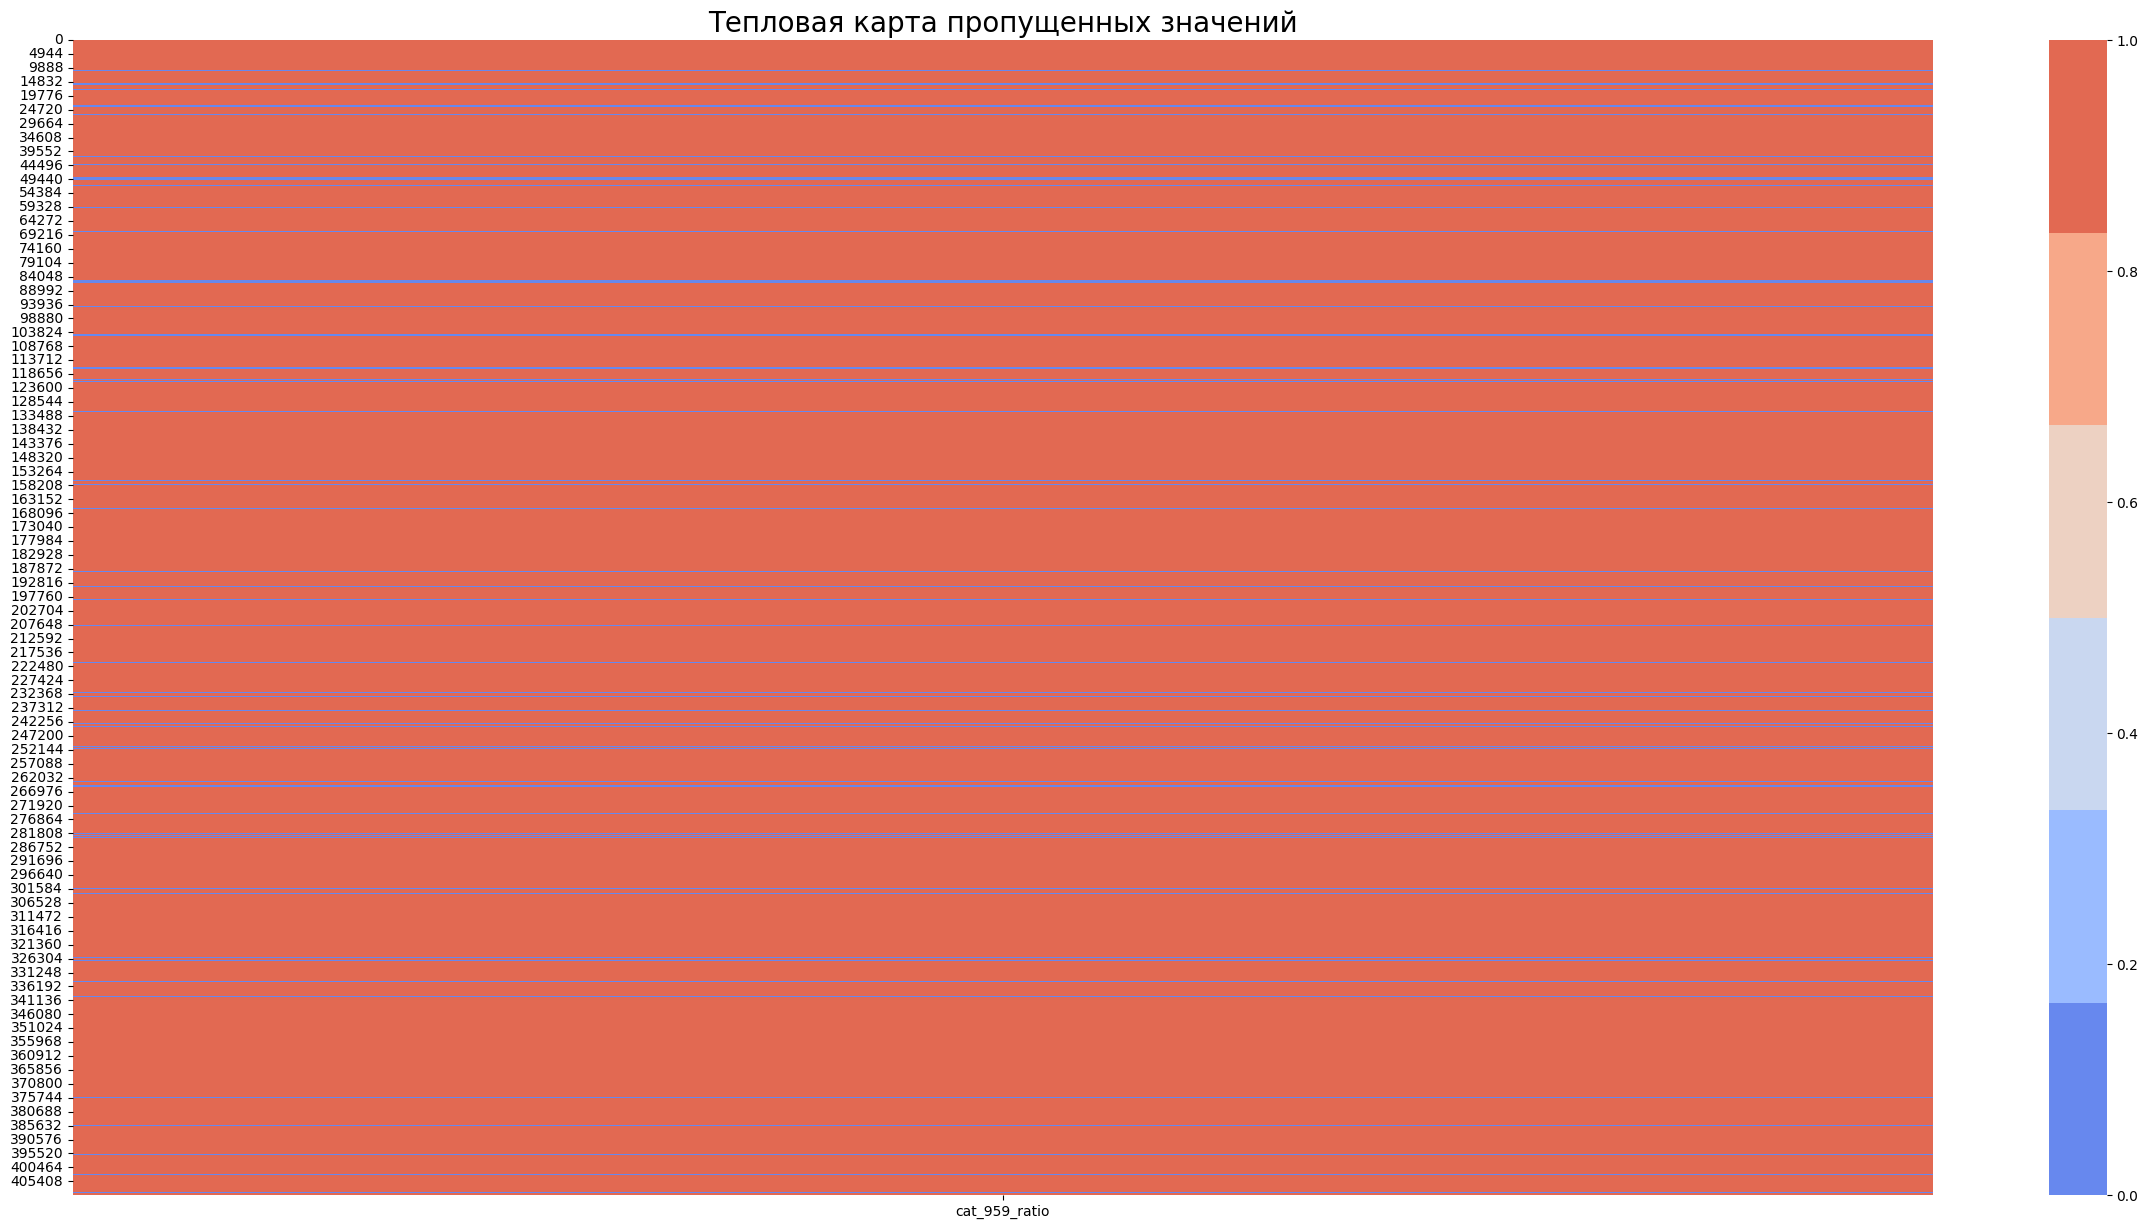

--------------------------------------------------------------------------------------------------------------


<Axes: title={'center': 'Тепловая карта пропущенных значений'}>

In [50]:
# Выводим количество пропусков
missing_values_count(
    data = user_item_features,
    data_name = 'user_item_features',
    length = 50
)
print('\n')



# Выводим тепловую карту
missing_values_heatmap(data = user_item_features)

**Вывод:**

$94.56886$% пропусков означает, что ~$94.57$% пользователей в тренировочной выборке не взаимодействовали с категорией `959.0` что может быть нормальным, если категория редкая, но имеет высокую конверсию (как показал $Z$-тест).

Заполним пропуски нулевым значением + добавим индикатор пропусков:

In [51]:
# Добавляем индикатор пропусков
user_item_features['cat_959_missing'] = user_item_features['cat_959_ratio'].isna().astype(int)

# Заполняем пропущенные значения нулём
user_item_features['cat_959_ratio'] = user_item_features['cat_959_ratio'].fillna(0)




# Выводим результаты
print('\nИнформация по пропущенным значениям после обработки:\n\n')
print('Количество пропусков в "cat_959_ratio" после обработки: {}'.format(user_item_features['cat_959_ratio'].isna().sum()))
print('-' * 60)
print('Доля "cat_959_missing = 1": {}'.format(user_item_features['cat_959_missing'].mean() * 100))
print('-' * 45)


Информация по пропущенным значениям после обработки:


Количество пропусков в "cat_959_ratio" после обработки: 0
------------------------------------------------------------
Доля "cat_959_missing = 1": 94.56885983832092
---------------------------------------------


=============================================================================================================================================

## <CENTER> **`6.` Machine Learning**

На данном этапе проведём эксперименты со следующими моделями:

  * **`Popularity-based`**;

  * **`Item-based Collaborative Filtering`**;

  * **`Matrix Factorization`**;

  * **`Wide & Deep` (нейросетевая)**.

#### $6.1$

#### **Подготовка данных к обучению.**

Создаём интерактивную матрицу:

In [52]:
# Создаём матрицу
interactions_matrix = (
    train_data.groupby(['visitorid', 'itemid'])['event'].count().reset_index(name = 'weight')
)



# Выводим результат
check_data_inf(
    data = interactions_matrix.head(),
    data_name = 'interactions_matrix',
    length1 = 40,
    length2 = 40
)


Данные таблицы "interactions_matrix" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 3.
----------------------------------------


,visitorid,itemid,weight
0,7,139394,1
1,7,164941,1
2,7,226353,1
3,12,70225,1
4,14,330269,1


----------------------------------------


Создаём функцию для рассчёта следующих метрик:

  * `Precision@K`,

  * `Recall@K`,
  
  * `nDCG@K (Normalized Discounted Cumulative Gain)`:

In [53]:
# -----| Функция для оценки рекомендаций (implicit) |-----
def evaluate_recommendations_implicit(recommendations_df, test_df, k=5):
    
    
    ''' 
    Оценка implicit-рекомендаций:
    Precision@k, Recall@k, nDCG@k, MAP@k
    
    recommendations_df:
        visitorid | itemid | score
        
    train_df:
        visitorid | itemid | weight
        
    test_df:
        visitorid | itemid | weight
    '''
    
    
    # -----| Формируем словарь релевантных items из test |-----
    test_user_items = (
        test_df
        .groupby('visitorid')['itemid']
        .apply(set)
        .to_dict()
    )
    
    # -----| Инициализируем списки для метрик |-----
    precisions = []
    recalls = []
    ndcgs = []
    maps = []
    
    
    
    # -----| Проходим по каждому пользователю в рекомендациях |-----
    evaluated_users = recommendations_df['visitorid'].unique()
    users_evaluated = 0
    
    # Проходим по каждому пользователю в рекомендациях
    for user in evaluated_users:
        
        # Получаем релевантные items для текущего пользователя из test
        true_items = test_user_items.get(user, set())
        if len(true_items) == 0:
            continue
        
        # Считаем количество пользователей, для которых есть релевантные items
        users_evaluated += 1
        
        # Получаем рекомендации для текущего пользователя и сортируем по score
        recs = (
            recommendations_df[recommendations_df['visitorid'] == user]
            .sort_values('score', ascending=False)
            .head(k)
        )
        
        # Преобразуем рекомендованные items в множество для удобства сравнения
        rec_list = recs['itemid'].tolist()
        rec_set = set(rec_list)
        
        # Находим пересечение рекомендованных items и релевантных items
        hits = rec_set & true_items
        
        # --- Рассчёт метрики Precision@k ---
        precisions.append(len(hits) / k)
        
        # --- Рассчёт метрики Recall@k ---
        recalls.append(len(hits) / len(true_items))
        
        # --- Рассчёт метрики nDCG@k ---
        rel = [1 if item in true_items else 0 for item in rec_list]       # релевантность для рекомендованных items
        dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))          # DCG для рекомендованных items
        ideal_rel = sorted(rel, reverse=True)                             # идеальный порядок релевантности
        idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal_rel))   # IDCG для идеального порядка
        ndcgs.append(dcg / idcg if idcg > 0 else 0)                       # нормализованный DCG
        
        # --- Рассчёт метрики MAP@k ---
        ap = 0
        hit = 0
        
        # Проходим по рекомендованным items и считаем AP
        for i, item in enumerate(rec_list):
            if item in true_items:
                hit += 1
                ap += hit / (i + 1)
        
        # Нормализуем AP на количество релевантных items
        ap = ap / len(true_items) if len(true_items) > 0 else 0
        maps.append(ap)
    
    
    
    # Возвращаем средние значения метрик и количество пользователей, для которых были рассчитаны метрики
    return {
        f'Precision@{k}': np.mean(precisions) if precisions else 0,
        f'Recall@{k}': np.mean(recalls) if recalls else 0,
        f'nDCG@{k}': np.mean(ndcgs) if ndcgs else 0,
        f'MAP@{k}': np.mean(maps) if maps else 0,
        'UsersEvaluated': users_evaluated
    }

#### $6.2$

#### **Popularity-based model.**

Создаём класс модели **Popularity-based**:

In [54]:
# -----| Создание класса модели рекомендаций на основе популярности товаров |-----
class PopularItemsRecommender:
    
    
    '''         
    
    Класс модели рекомендаций на основе популярности товаров.
    
    Параметры:
        - interactions: DataFrame с колонками 'visitorid', 'itemid' и 'weight', представляющий взаимодействия пользователей с товарами.
        - item_features: DataFrame с дополнительными характеристиками товаров (опционально).
        - min_interactions: минимальное число взаимодействий, необходимое для включения товара в список популярных.
    
    '''
    
    
    # -----| Инициализация параметров |-----
    def __init__(self, interactions, item_features=None, min_interactions=5):
        
        '''         
        Инициализация модели рекомендаций на основе популярности товаров.
        
        Параметры:
            - interactions: DataFrame с колонками 'visitorid', 'itemid' и 'weight', представляющий взаимодействия пользователей с товарами.
            - item_features: DataFrame с дополнительными характеристиками товаров (опционально).
            - min_interactions: минимальное число взаимодействий, необходимое для включения товара в список популярных.
        '''
        
        # Проверка входных данных 
        if interactions is None:
            raise ValueError('interactions не может быть None')
        
        if not isinstance(interactions, pd.DataFrame):
            raise TypeError('interactions должен быть DataFrame')
        
        if 'visitorid' not in interactions.columns or 'itemid' not in interactions.columns or 'weight' not in interactions.columns:
            raise ValueError("interactions должен содержать колонки 'visitorid', 'itemid', и 'weight'")
        
        # Сохраняем входные данные и рассчитываем популярность товаров
        self.interactions = interactions.copy()         # сохраняем копию данных о взаимодействиях
        self.item_features = item_features              # сохраняем дополнительные характеристики товаров
        
        # Считаем статистику по товарам
        stats = interactions.groupby('itemid').agg(
            total_weight = ('weight', 'sum'),
            n_interactions = ('weight', 'count'),
            n_users = ('visitorid', 'nunique')
        ).reset_index()
        
        # Фильтр по минимальному числу взаимодействий
        stats = stats[stats['n_interactions'] >= min_interactions]
        
        # Рассчитываем скоринг
        stats['score'] = (
            stats['total_weight'] * np.log1p(stats['n_users'])
        )
        
        # Добавляем item_features
        if item_features is not None:
            stats = stats.merge(
                item_features,
                on = 'itemid',
                how = 'left'
            )
        
        # Сортируем товары по убыванию популярности и сохраняем результат
        self.popular_items = (
            stats
            .sort_values('score', ascending = False)
            .reset_index(drop = True)
        )
        
        
        
        
        
    # -----| Выводим топ-N популярных товаров |-----
    def get_top_n(self, n = 10):
        
        '''        
        Возвращает топ-N популярных товаров.
        
        Параметры:
            - n: количество товаров для возврата.
        '''
        
        # Проверка входного параметра
        if not isinstance(n, int) or n <= 0:
            raise ValueError('n должен быть положительным целым числом')
        
        # Возвращаем топ-N популярных товаров
        return self.popular_items.head(n)
    
    
    
    
    
    # --- Рекомендации для пользователя ---
    def recommendation_for_user(self, user_id, n=3):
        
        '''
        Рекомендует топ-N популярных товаров для конкретного пользователя, исключая уже взаимодействовавшие товары.
        
        Параметры:
            - user_id: идентификатор пользователя для которого нужно сделать рекомендации.
            - n: количество товаров для рекомендации.
        '''
        
        # Проверка входных параметров
        if user_id is None:
            raise ValueError('user_id не может быть None')
        if not isinstance(user_id, (int, str)):
            raise TypeError('user_id должен быть строкой или целым числом')
        if not isinstance(n, int) or n <= 0:
            raise ValueError('n должен быть положительным целым числом')
        
        # Получаем список товаров, с которыми пользователь уже взаимодействовал
        seen = set(
            self.interactions[
                self.interactions['visitorid'] == user_id
            ]['itemid']
        )
        
        # Рекомендуем топ-N популярных товаров, исключая уже взаимодействовавшие
        recs = self.popular_items[
            ~self.popular_items['itemid'].isin(seen)
        ].head(n)
        
        # Возвращаем рекомендации
        return recs[['itemid', 'score']]

Выводим топ-10 товаров:

In [55]:
# Выводим информацию по модели рекомендаций на основе популярных товаров
print('\n')
print('-' * 87)
print('==========| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ПОПУЛЯРНЫХ ТОВАРОВ |==========')
print('-' * 87)



# -----| Инициализация модели |-----
PR_model = PopularItemsRecommender(
    interactions = interactions_matrix,
    item_features = item_features,
    min_interactions = 10
)

# Получаем топ-10 популярных товаров
PR_model.get_top_n(10)



---------------------------------------------------------------------------------------
==========| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ПОПУЛЯРНЫХ ТОВАРОВ |==========
---------------------------------------------------------------------------------------


,itemid,total_weight,n_interactions,n_users,score,view_count,transaction_count,conversion_rate,categoryid,parentid,category_depth,avg_view_time,unique_users,views_per_user
0,369447,993,486,486,6144.946274,962,31.0,3.222453,48.0,500.0,2,1.431566e+12,486,1.979424
1,370653,685,587,587,4368.057959,685,0.0,0.000000,82.0,1125.0,3,1.431962e+12,587,1.166951
2,298009,578,470,470,3557.507978,578,0.0,0.000000,529.0,623.0,3,1.431981e+12,470,1.229787
3,96924,458,390,390,2733.668062,458,0.0,0.000000,56.0,1497.0,2,1.432005e+12,390,1.174359
4,309778,441,289,289,2500.417487,438,3.0,0.684932,683.0,1606.0,3,1.432135e+12,289,1.515571
5,335975,424,360,360,2496.884254,424,0.0,0.000000,48.0,500.0,2,1.431829e+12,360,1.177778
6,37029,383,291,291,2174.196706,378,5.0,1.322751,1483.0,561.0,2,1.431724e+12,291,1.298969
7,290250,369,337,337,2148.703935,369,0.0,0.000000,352.0,859.0,1,1.432301e+12,337,1.094955
8,111530,389,246,246,2143.152063,385,4.0,1.038961,1625.0,1141.0,3,1.431876e+12,246,1.565041
9,257040,394,222,222,2130.425678,390,4.0,1.025641,683.0,1606.0,3,1.431935e+12,222,1.756757


Генерируем рекомендации для конкретного пользователя:

In [56]:
# Выводим информацию по рекомендациям для пользователя с id = '123' 
print('\n')
print('-' * 87)
print('===================| ИНФОРМАЦИЯ ПО РЕКОМЕНДАЦИЯМ ДЛЯ ПОЛЬЗОВАЕТЛЯ |===================')
print('-' * 87)



# Выводим рекомендации
PR_model.recommendation_for_user(
    user_id = 123,
    n = 10
)



---------------------------------------------------------------------------------------
===================| ИНФОРМАЦИЯ ПО РЕКОМЕНДАЦИЯМ ДЛЯ ПОЛЬЗОВАЕТЛЯ |===================
---------------------------------------------------------------------------------------


,itemid,score
0,369447,6144.946274
1,370653,4368.057959
2,298009,3557.507978
3,96924,2733.668062
4,309778,2500.417487
5,335975,2496.884254
6,37029,2174.196706
7,290250,2148.703935
8,111530,2143.152063
9,257040,2130.425678


Рассчитываем метрики качества модели:

In [57]:
# Создаём список для хранения рекомендаций от модели на основе популярных книг
pop_recs = []

# Ограничиваем количество пользователей для оценки, чтобы ускорить процесс
users_eval = test_data['visitorid'].unique()[:1000]  # ограничиваем количество пользователей для оценки





# Проходим по каждому пользователю в тестовой выборке и получаем рекомендации от модели на основе популярных книг для каждого пользователя, исключая уже взаимодействовавшие товары. 
# Результаты сохраняем в список pop
for uid in users_eval:
    
    # Получаем рекомендации для текущего пользователя от модели на основе популярных книг
    rec = PR_model.recommendation_for_user(
        user_id = int(uid),
        n = 5
    )
    
    # Проверяем, что рекомендации не пустые, и если есть рекомендации, 
    # добавляем их в список pop_recs, добавляя столбец 'visitorid' для идентификации пользователя
    if not rec.empty:
        rec = rec.copy()
        rec['visitorid'] = int(uid)   
        pop_recs.append(rec)


# Конкатенируем все рекомендации в один DataFrame
pop_recommendations = pd.concat(pop_recs, ignore_index=True)

# Оцениваем рекомендации от модели на основе популярных книг, используя функцию evaluate_recommendations,
pop_metrics = evaluate_recommendations_implicit(
    recommendations_df = pop_recommendations,
    test_df = test_data,
    k = 5
)




# Выводим результаты
print('\n')
print('-' * 91)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============')
print('-' * 91)
display(pop_metrics)
print('-' * 91)



-------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============
-------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.003),
 'Recall@5': np.float64(0.005639944001288154),
 'nDCG@5': np.float64(0.006973958134829118),
 'MAP@5': np.float64(0.0016707557905488927),
 'UsersEvaluated': 1000}

-------------------------------------------------------------------------------------------


#### $6.3$

#### **Item-based Collaborative Filtering.**

Создаём класс модели **ItemBasedCF**:

In [55]:
# -----| Создаём класс модели коллаборативной фильтрации на основе схожести товаров для implicit feedback |-----
class ItemBasedCFRecommender:
    
    '''         
    
    Класс модели коллаборативной фильтрации на основе схожести товаров для implicit feedback.
    
    Параметры:
        - interactions: DataFrame с колонками 'visitorid', 'itemid' и 'weight', представляющий взаимодействия пользователей с товарами.
        - top_n_similar: количество наиболее схожих товаров для хранения в модели (по умолчанию 50).
        - min_interactions: минимальное число взаимодействий, необходимое для включения товара в модель (по умолчанию 5).
    
    Методы:
        - fit(): обучает модель на предоставленных данных о взаимодействиях.
        - recommend(user_id, k=5): генерирует топ-k рекомендаций для заданного пользователя.
    
    '''
    
    
    # -----| Инициализация параметров |-----
    def __init__(self, interactions, top_n_similar=50, min_interactions=5):
        
        '''        
        Инициализация модели коллаборативной фильтрации на основе схожести товаров для implicit feedback.
        
        Параметры:
            - interactions: DataFrame с колонками 'visitorid', 'itemid' и 'weight', представляющий взаимодействия пользователей с товарами.
            - top_n_similar: количество наиболее схожих товаров для хранения в модели (по умолчанию 50).
            - min_interactions: минимальное число взаимодействий, необходимое для включения товара в модель (по умолч
        '''

        self.train_df = interactions.copy()          # сохраняем копию данных о взаимодействиях
        self.top_n_similar = top_n_similar           # сохраняем количество наиболее схожих товаров для хранения в модели
        self.min_interactions = min_interactions     # сохраняем минимальное число взаимодействий, необходимое для включения товара в модель

        self.item_index = None                       # словарь для преобразования itemid в индекс
        self.index_item = None                       # словарь для преобразования индекса обратно в itemid
        self.user_item_sparse = None                 # разреженная матрица пользователь–товар
        self.item_similarity = None                  # разреженная матрица схожести товаров
        self.top_similar_items = None                # словарь для хранения топ-N схожих товаров для каждого товара

    
    
    
    
    # -----| Метод для построения разреженной матрицы пользователь–товар |-----
    def build_matrix(self):
        
        '''        
        Построение разреженной матрицы пользователь–товар на основе предоставленных данных о взаимодействиях.
        '''

        # Фильтр редких товаров
        item_counts = self.train_df['itemid'].value_counts()
        valid_items = item_counts[item_counts >= self.min_interactions].index
        
        # Фильтруем исходный DataFrame, оставляя только товары, которые встречаются достаточно часто
        df = self.train_df[self.train_df['itemid'].isin(valid_items)]
        
        # Получаем уникальные пользователи и товары
        users = df['visitorid'].unique()
        items = df['itemid'].unique()
        
        # Создаём словари для преобразования itemid в индекс и обратно
        self.item_index = {iid: i for i, iid in enumerate(items)}
        self.index_item = {i: iid for iid, i in self.item_index.items()}
        
        # Преобразуем visitorid и itemid в числовые коды для построения разреженной матрицы
        user_codes = df['visitorid'].astype('category').cat.codes
        item_codes = df['itemid'].map(self.item_index)
        
        # Строим разреженную матрицу пользователь–товар, используя веса взаимодействий в качестве значений
        matrix = csr_matrix(
            (df['weight'], (user_codes, item_codes)),
            shape=(len(users), len(items))
        )
        
        # Сохраняем разреженную матрицу в атрибуте класса
        self.user_item_sparse = matrix
        
        # Выводим информацию о разреженной матрице
        print(f"Matrix shape: {matrix.shape}")
        print(f"Sparsity: {1 - matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.6f}")
        
        # Возвращаем разреженную матрицу
        return matrix





    # -----| Метод для обучения модели и вычисления схожести товаров |-----
    def fit(self):
        
        '''         
        Обучение модели коллаборативной фильтрации на основе схожести товаров для implicit feedback.
        Вычисление схожести товаров и сохранение топ-N схожих товаров для каждого товара.
        '''
        
        # Построение разреженной матрицы пользователь–товар
        matrix = self.build_matrix()
        
        # Вычисление схожести товаров с помощью косинусного расстояния
        self.item_similarity = cosine_similarity(
            matrix.T,
            dense_output = False
        )
        
        # Сохранение топ-N схожих товаров для каждого товара
        n_items = matrix.shape[1]
        self.top_similar_items = {}
        
        # Проходим по каждому товару и сохраняем топ-N схожих товаров
        for i in range(n_items):
            
            # Получаем строку схожести для текущего товара
            row = self.item_similarity.getrow(i)
            
            # Если нет схожих товаров, пропускаем текущий товар
            if row.nnz == 0:
                continue
            
            # Получаем индексы и значения топ-N схожих товаров, сортируя по убыванию схожести
            sorted_idx = np.argsort(-row.data)[:self.top_n_similar]
            
            # Получаем индексы и значения топ-N схожих товаров
            top_indices = row.indices[sorted_idx]
            top_values = row.data[sorted_idx]
            
            # Сохраняем топ-N схожих товаров для текущего товара в словаре
            self.top_similar_items[i] = list(zip(top_indices, top_values))





    # -----| Метод для генерации рекомендаций для пользователя |-----
    def recommendations_for_user(self, user_id, k=5):
        
        '''
        Генерация топ-k рекомендаций для заданного пользователя на основе схожести товаров.
        Параметры:
            - user_id: идентификатор пользователя для которого нужно сделать рекомендации.
            - k: количество товаров для рекомендации.
        '''
        
        # Проверка входных параметров
        if user_id is None:
            raise ValueError('user_id не может быть None')
        if not isinstance(user_id, (int, str)):
            raise TypeError('user_id должен быть строкой или целым числом')
        if not isinstance(k, int) or k <= 0:
            raise ValueError('k должен быть положительным целым числом')
        
        # Проверяем, обучена ли модель, и если нет, обучаем её
        if self.top_similar_items is None:
            self.fit()
        
        # Получаем список товаров, с которыми пользователь уже взаимодействовал
        user_items = self.train_df[
            self.train_df['visitorid'] == user_id
        ]['itemid'].unique()
        
        # Если пользователь не взаимодействовал ни с одним товаром, возвращаем пустой список рекомендаций
        if len(user_items) == 0:
            return []
        
        # Инициализируем словарь для хранения кандидатов на рекомендацию и их скорингов
        candidates = {}
        
        # Проходим по каждому товару, с которым пользователь уже взаимодействовал
        for iid in user_items:
            
            # Получаем индекс товара в модели
            idx = self.item_index.get(iid)
            if idx is None:
                continue
            
            # Получаем топ-N схожих товаров для текущего товара
            similar = self.top_similar_items.get(idx, [])
            
            # Проходим по каждому схожему товару и его скорингу
            for sim_idx, sim_score in similar:
                
                # Получаем идентификатор товара по индексу
                cand = self.index_item[sim_idx]
                
                # Если кандидат не входит в список уже взаимодействовавших товаров, 
                # добавляем его в словарь кандидатов с накоплением скоринга
                if cand not in user_items:
                    candidates[cand] = candidates.get(cand, 0) + sim_score
        
        # Если нет кандидатов, возвращаем пустой список рекомендаций
        if not candidates:
            return []
        
        # Сортируем кандидатов по скорингу в порядке убывания и возвращаем топ-k рекомендаций
        ranked = sorted(
            candidates,
            key = candidates.get,
            reverse = True
        )[:k]
        
        
        # Возвращаем рекомендации в виде списка идентификаторов товаров
        return ranked

Генерируем рекомендации:

In [ ]:
# Задаём заглавие для информации по модели 
print('\n')
print('-' * 106)
print('==================================| ITEM-BASED COLLABORATIVE FILTERING |==================================')
print('-' * 106)





# Инициализация модели коллаборативной фильтрации на основе схожести товаров для implicit feedback
IBCF_recommender = ItemBasedCFRecommender(
    interactions = interactions_matrix,
    top_n_similar = 50,
    min_interactions = 5
)

# Обучение модели и вычисление схожести товаров
IBCF_recommender.fit()

# Генерация рекомендаций
ibcf_recs = []
test_users_sample = test_data['visitorid'].unique()[:200]


# Проходим по каждому пользователю в тестовой выборке и получаем рекомендации 
for uid in test_users_sample:
    
    # Получаем рекомендации для текущего пользователя 
    rec_items = IBCF_recommender.recommendations_for_user(
        user_id = int(uid),
        k = 5
    )
    
    # Проверяем, что рекомендации не пустые
    if len(rec_items) > 0:
        
        # Создаём DataFrame для рекомендаций текущего пользователя, 
        # добавляя столбец 'visitorid' для идентификации пользователя 
        # и столбец 'score' для хранения порядкового номера рекомендации (чем выше, тем более релевантная рекомендация)
        rec_df = pd.DataFrame(
            {
                'visitorid': int(uid),
                'itemid': rec_items,
                'score': range(len(rec_items), 0, -1)  
            }
        )
        
        # Добавляем DataFrame с рекомендациями текущего пользователя в список ibcf_recs
        ibcf_recs.append(rec_df)





# Конкатенируем все рекомендации в один DataFrame
ibcf_recommendations = pd.concat(ibcf_recs, ignore_index = True)

# Выводим рекомендации для первых 10 пользователей
display(ibcf_recommendations.head(10))
print('-' * 106)



----------------------------------------------------------------------------------------------------------
==================================| ITEM-BASED COLLABORATIVE FILTERING |==================================
----------------------------------------------------------------------------------------------------------
Matrix shape: (191801, 20706)
Sparsity: 0.999928


,visitorid,itemid,score
0,396655,323455,5
1,396655,369965,4
2,396655,107972,3
3,396655,441256,2
4,396655,228157,1
5,1161163,237763,5
6,1161163,3962,4
7,1161163,282692,3
8,1161163,151855,2
9,1161163,461915,1


----------------------------------------------------------------------------------------------------------


Рассчитываем метрики качества модели:

In [57]:
# Вычисление метрик для Item-Based CF модели
ibcf_metrics = evaluate_recommendations_implicit(
    recommendations_df = ibcf_recommendations,
    test_df = test_data,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 100)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ ITEM-BASED COLLABORATIVE FILTERING |============')
print('-' * 100)
display(ibcf_metrics)
print('-' * 100)



----------------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ ITEM-BASED COLLABORATIVE FILTERING |============
----------------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.06153846153846154),
 'Recall@5': np.float64(0.07751395960332075),
 'nDCG@5': np.float64(0.17490043188223717),
 'MAP@5': np.float64(0.05140022781810005),
 'UsersEvaluated': 13}

----------------------------------------------------------------------------------------------------


**Вывод:**

При sparsity = 0.9998 item-based CF не формирует рекомендации из-за отсутствия пересечений. В связи с этим предпочтение отдано латентным моделям (MF).

#### $6.4$

#### **Matrix Factorization (SVD).**

Произведём маппинг:

In [61]:
# -----| Функция для построения словарей отображения идентификаторов пользователей и товаров в числовые индексы |-----
def build_mappings(data):
    
    '''         
    Функция для построения словарей отображения идентификаторов пользователей и товаров в числовые индексы.
    
    На вход функции передаётся DataFrame с колонками 'visitorid' и 'itemid', представляющий взаимодействия пользователей с товарами.
    Функция возвращает два словаря:
        - user_to_idx: словарь, отображающий идентификаторы пользователей (visitorid) в числовые индексы (0, 1, 2, ...).
        - item_to_idx: словарь, отображающий идентификаторы товаров (itemid) в числовые индексы (0, 1, 2, ...).
    '''
    
    # Получаем уникальные идентификаторы пользователей и товаров из предоставленных данных
    user_ids = data['visitorid'].unique()
    item_ids = data['itemid'].unique()
    
    # Строим словари отображения идентификаторов пользователей и товаров в числовые индексы
    user_to_idx = {u: i for i, u in enumerate(user_ids)}
    item_to_idx = {i: j for j, i in enumerate(item_ids)}
    
    # Возвращаем словари отображения идентификаторов пользователей и товаров в числовые индексы
    return user_to_idx, item_to_idx

Подготовка позитивных взаимодействий:

In [62]:
# Выводим информацию по построению словарей отображения идентификаторов пользователей и товаров в числовые индексы
print('\n')
print('-' * 110)
print('========| ПОСТРОЕНИЕ СЛОВАРЕЙ ОТОБРАЖЕНИЯ ИДЕНТИФИКАТОРОВ ПОЛЬЗОВАТЕЛЕЙ И ТОВАРОВ В ЧИСЛОВЫЕ ИНДЕКСЫ |========')
print('-' * 110)



# Строим словари отображения идентификаторов пользователей и товаров в числовые индексы на основе матрицы взаимодействий
user_to_idx, item_to_idx = build_mappings(data = interactions_matrix)

# Выводим первые 10 элементов словаря отображения идентификаторов пользователей в числовые индексы
interactions_mapped = interactions_matrix.copy()
interactions_mapped['user_idx'] = interactions_mapped['visitorid'].map(user_to_idx)
interactions_mapped['item_idx'] = interactions_mapped['itemid'].map(item_to_idx)

# Выводим результат
check_data_inf(
    data = interactions_mapped.head(),
    data_name = 'interactions_mapped',
    length1 = 40,
    length2 = 40
)



# Преобразуем идентификаторы пользователей и товаров в числовые индексы 
# и сохраняем результат в виде тензоров для дальнейшего использования в модели рекомендаций на основе нейронных сетей
train_users = torch.tensor(interactions_mapped['user_idx'].values, dtype=torch.long)
train_items = torch.tensor(interactions_mapped['item_idx'].values, dtype=torch.long)

# Выводим результат
print('\n\n')
print('-' * 110)
print('================| ПРЕОБРАЗОВАНИЕ ИДЕНТИФИКАТОРОВ ПОЛЬЗОВАТЕЛЕЙ И ТОВАРОВ В ЧИСЛОВЫЕ ИНДЕКСЫ |================')
print('-' * 110)
print('Первые 10 значений train_users:', train_users[:10])
print('Первые 10 значений train_items:', train_items[:10])



--------------------------------------------------------------------------------------------------------------
========| ПОСТРОЕНИЕ СЛОВАРЕЙ ОТОБРАЖЕНИЯ ИДЕНТИФИКАТОРОВ ПОЛЬЗОВАТЕЛЕЙ И ТОВАРОВ В ЧИСЛОВЫЕ ИНДЕКСЫ |========
--------------------------------------------------------------------------------------------------------------

Данные таблицы "interactions_mapped" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 5.
----------------------------------------


,visitorid,itemid,weight,user_idx,item_idx
0,7,139394,1,0,0
1,7,164941,1,0,1
2,7,226353,1,0,2
3,12,70225,1,1,3
4,14,330269,1,2,4


----------------------------------------



--------------------------------------------------------------------------------------------------------------
================| ПРЕОБРАЗОВАНИЕ ИДЕНТИФИКАТОРОВ ПОЛЬЗОВАТЕЛЕЙ И ТОВАРОВ В ЧИСЛОВЫЕ ИНДЕКСЫ |================
--------------------------------------------------------------------------------------------------------------
Первые 10 значений train_users: tensor([0, 0, 0, 1, 2, 3, 4, 4, 5, 6])
Первые 10 значений train_items: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


Создадим словарь user → set(items):

In [63]:
# Создаём словарь для хранения множества положительных взаимодействий (товаров) для каждого пользователя
user_pos_items = defaultdict(set)


# Проходим по каждой строке в interactions_mapped 
# и добавляем индекс товара в множество положительных взаимодействий для соответствующего пользователя
for u, i in zip(interactions_mapped['user_idx'], interactions_mapped['item_idx']):
    user_pos_items[u].add(i)

Функция семплинга:

In [64]:
# -----| Функция для сэмплирования негативного примера (товара) для заданного пользователя |-----
def sample_negative(user, n_items):
    
    '''         
    Функция для сэмплирования негативного примера (товара) для заданного пользователя.
    
    Параметры:
        - user: числовой индекс пользователя, для которого нужно сэмплировать негативный пример.
        - n_items: общее количество уникальных товаров в данных, используемое для генерации случайного индекса товара.
    '''
    
    # Сэмплируем случайный индекс товара и проверяем, 
    # что он не входит в множество положительных взаимодействий для данного пользователя.
    while True:
        
        # Сэмплируем случайный индекс товара от 0 до n_items - 1
        neg_item = random.randint(0, n_items - 1)
        
        # Если сэмплированный индекс товара не входит в множество положительных взаимодействий для данного пользователя,
        if neg_item not in user_pos_items[user]:
            
            # Возвращаем сэмплированный негативный пример (индекс товара)
            return neg_item

Создаём класс модели **MatrixFactorization**:

In [65]:
# -----| Создаём класс модели рекомендаций на основе нейронных сетей для implicit feedback |-----
class ImplicitMF(nn.Module):
    
    
    '''
    Класс модели рекомендаций на основе нейронных сетей для implicit feedback.
    
    Параметры:
        - n_users: общее количество уникальных пользователей в данных, используемое для определения размера эмбеддингов пользователей.
        - n_items: общее количество уникальных товаров в данных, используемое для определения размера эмбеддингов товаров.
        - n_factors: размерность эмбеддингов пользователей и товаров, определяющая количество скрытых факторов в модели (по умолчанию 64).
    
    Методы:
        - forward(u, i): метод для прямого прохода, который принимает тензоры с индексами пользователей и товаров и возвращает предсказанные оценки взаимодействий.
        - recommendation_for_user(user_id, user_to_idx, item_to_idx, interactions_df, k=5, device='cpu'): метод для генерации рекомендаций для конкретного пользователя, который принимает идентификатор пользователя, словари отображения идентификаторов в индексы, DataFrame с взаимодействиями и
        
    Возвращает DataFrame с топ-k рекомендациями для данного пользователя.
    '''
    
    
    
    # -----| Инициализация параметров |-----
    def __init__(self, n_users, n_items, n_factors=64):
        super().__init__()
        
        # Инициализируем эмбеддинги для пользователей и товаров с помощью nn.Embedding
        self.user_emb = nn.Embedding(n_users, n_factors)     # эмбеддинги для пользователей
        self.item_emb = nn.Embedding(n_items, n_factors)     # эмбеддинги для товаров
        
        # Инициализируем веса эмбеддингов с помощью нормального распределения с малой дисперсией
        nn.init.normal_(self.user_emb.weight, std=0.01)      # инициализация весов эмбеддингов пользователей
        nn.init.normal_(self.item_emb.weight, std=0.01)      # инициализация весов эмбеддингов товаров
    
    
    
    
    
    # -----| Метод для прямого прохода |-----
    def forward(self, u, i):
        
        '''         
        Метод для прямого прохода, который принимает тензоры с индексами пользователей и товаров.
        Возвращает предсказанные оценки взаимодействий.
        '''
        
        # Получаем эмбеддинги для пользователей и товаров на основе входных индексов
        return (self.user_emb(u) * self.item_emb(i)).sum(1)
    
    
    
    
    
    # -----| Метод .recommendation_for_user() (генерация рекомендаций) |-----
    def recommendation_for_user(self, user_id, user_to_idx, item_to_idx, interactions_df, k=5, device='cpu'):
        
        '''         
        Метод для генерации рекомендаций для конкретного пользователя.
        Принимает идентификатор пользователя, словари отображения идентификаторов в индексы, DataFrame с взаимодействиями и количество рекомендаций k.
        Возвращает DataFrame с топ-k рекомендациями для данного пользователя.
        '''
        
        # Проверяем, что идентификатор пользователя существует в словаре отображения, 
        # и если нет, возвращаем пустой DataFrame с нужными колонками
        if user_id not in user_to_idx:
            return pd.DataFrame(columns = ['visitorid', 'itemid', 'score'])
        
        # Устанавливаем модель в режим оценки (eval), 
        # чтобы отключить градиенты и другие механизмы, используемые при обучении модели, 
        # и оптимизировать производительность при генерации рекомендаций
        self.eval()
        
        # Получаем числовой индекс пользователя из словаря отображения
        uidx = user_to_idx[user_id]
        
        # Получаем множество товаров, с которыми пользователь уже взаимодействовал, чтобы исключить их из рекомендаций
        read_items = set(
            interactions_df[interactions_df['visitorid'] == user_id]['itemid']
        )
        
        # Формируем список кандидатов на рекомендацию, исключая уже взаимодействовавшие товары, 
        # и преобразуем их в числовые индексы для подачи в модель
        candidates = [i for i in item_to_idx if i not in read_items]
        
        # Если нет кандидатов, возвращаем пустой DataFrame с нужными колонками
        if not candidates:
            return pd.DataFrame(columns = ['visitorid', 'itemid', 'score'])
        
        # Преобразуем список кандидатов в числовые индексы для подачи в модель
        item_indices = torch.tensor(
            [item_to_idx[i] for i in candidates],
            dtype = torch.long,
            device = device
        )
        
        # Создаём тензор с индексом пользователя, повторённым столько раз, сколько кандидатов, для подачи в модель
        user_tensor = torch.tensor(
            [uidx] * len(item_indices), 
            dtype = torch.long,
            device = device
        )
        
        # Получаем предсказанные оценки взаимодействий для всех кандидатов, используя модель, 
        # и перемещаем результат на CPU для дальнейшей обработки
        with torch.no_grad():
            scores = self(user_tensor, item_indices).cpu().numpy()
            
        # Сортируем кандидатов по предсказанным оценкам в порядке убывания и выбираем топ-k рекомендаций
        top_idx = scores.argsort()[::-1][:k]
        
        # Получаем идентификаторы товаров для топ-k рекомендаций на основе индексов и предсказанных оценок для топ-k рекомендаций
        top_items = [candidates[i] for i in top_idx]
        top_scores = scores[top_idx]
        
        
        
        # Возвращаем рекомендации в виде DataFrame с колонками 'visitorid', 'itemid' и 'score'
        return pd.DataFrame(
            {
                'visitorid': [user_id] * len(top_items),
                'itemid': top_items,
                'score': top_scores
            }
        )

Обучение с негативным семплированием:

In [ ]:
# Задаём заглавие для вывода информации по метрикам модели
print('\n')
print('-' * 110)
print('===============================| РАССЧЁТ МЕТРИК МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |===============================')
print('-' * 110)
print('\n')





# Инициализация модели рекомендаций на основе матричной факторизации для implicit feedback
IMF_model = ImplicitMF(
    n_users = len(user_to_idx),
    n_items = len(item_to_idx),
    n_factors = 64
).to(device)

# Задаём оптимизатор и функцию потерь для обучения модели
optimizer = torch.optim.Adam(IMF_model.parameters(), lr=0.003) 
loss_fn = nn.BCEWithLogitsLoss()

# Задаём количество эпох, размер батча и общее количество уникальных товаров для обучения модели 
epochs = 5
batch_size = 4096
n_items = len(item_to_idx)


# Циклом проходим по каждой эпохе обучения модели 
for epoch in range(epochs):
    
    # Устанавливаем модель в режим обучения (train), чтобы включить градиенты и другие механизмы, используемые при обучении модели
    IMF_model.train()
    total_loss = 0
    
    # Сэмплируем случайный порядок индексов для обучения модели в каждой эпохе, 
    # чтобы обеспечить разнообразие данных и улучшить обобщающую способность модели
    perm = torch.randperm(len(train_users))
    
    # Проходим по данным в батчах, используя сэмплированный порядок индексов, и обучаем модель на каждом батче
    for i in range(0, len(perm), batch_size):
        
        # Получаем индексы для текущего батча на основе сэмплированного порядка индексов
        idx = perm[i:i+batch_size]
        
        # Получаем положительные примеры (пары пользователь–товар) для текущего батча на основе индексов 
        # и перемещаем их на устройство (CPU или GPU) для обучения модели
        pos_u = train_users[idx].to(device)
        pos_i = train_items[idx].to(device)
        
        # Сэмплируем негативные примеры (товары) для каждого пользователя в текущем батче, 
        # исключая уже взаимодействовавшие товары, и сохраняем их в виде тензора на устройстве для обучения модели
        neg_i_list = []
        for u in pos_u.cpu().numpy():
            neg_i_list.append(sample_negative(u, n_items))
        
        # Преобразуем список сэмплированных негативных примеров в тензор и перемещаем его на устройство для обучения модели
        neg_i = torch.tensor(
            neg_i_list, 
            dtype = torch.long, 
            device = device
        )
        
        # Обнуляем градиенты оптимизатора перед обратным проходом, 
        # чтобы предотвратить накопление градиентов от предыдущих итераций обучения
        optimizer.zero_grad()
        
        # Получаем предсказанные оценки взаимодействий для положительных и негативных примеров, используя модель
        pos_scores = IMF_model(pos_u, pos_i)
        neg_scores = IMF_model(pos_u, neg_i)
        
        # Вычисляем функцию потерь для положительных примеров (которые должны быть близки к 1) 
        # и негативных примеров (которые должны быть близки к 0)
        loss = loss_fn(pos_scores, torch.ones_like(pos_scores)) + \
               loss_fn(neg_scores, torch.zeros_like(neg_scores))
        
        # Считаем градиенты и обновляем веса
        loss.backward()
        optimizer.step()
        
        # Добавляем ошибку в общую сумму
        total_loss += loss.item()
    
    # Выводим суммарную ошибку за эпоху
    print(f'Epoch {epoch+1}, Loss: {total_loss:.4f}')
print('-' * 25)



--------------------------------------------------------------------------------------------------------------
===============================| РАССЧЁТ МЕТРИК МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |===============================
--------------------------------------------------------------------------------------------------------------


Epoch 1, Loss: 139.9959
Epoch 2, Loss: 136.8487
Epoch 3, Loss: 123.4856
Epoch 4, Loss: 106.4103
Epoch 5, Loss: 94.3565
-------------------------


Генерируем рекомендации:

In [67]:
# Заголовок для получения рекомендаций от модели матричной факторизации
print('\n')
print('-' * 89)
print('=====================| ИНФОРМАЦИЯ ПО МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |=====================')
print('-' * 89)    


mf_recs = []
REL_THRESHOLD = 4
K = 5



# Получаем уникальных пользователей из тестовой выборки и ограничиваем их количеством для оценки модели
users_eval = test_data['visitorid'].unique()[:1000]

# Проходим по каждому пользователю из тестовой выборки и получаем рекомендации от модели
for uid in users_eval:
    rec = IMF_model.recommendation_for_user(
        user_id = uid,
        user_to_idx = user_to_idx,
        item_to_idx = item_to_idx,
        interactions_df = interactions_matrix,
        k = K,
        device = device
    )
    
    # Если рекомендации не пустые, добавляем их в список mf_recs для последующего объединения в DataFrame
    if not rec.empty:
        mf_recs.append(rec)
        
        
        
# Объединяем все рекомендации от модели матричной факторизации в один DataFrame и выводим первые 15 строк для оценки результатов
mf_recommendations = pd.concat(
    mf_recs,
    ignore_index = True
)

display(mf_recommendations.head(15))
print('-' * 89)



-----------------------------------------------------------------------------------------
=====================| ИНФОРМАЦИЯ ПО МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |=====================
-----------------------------------------------------------------------------------------


,visitorid,itemid,score
0,396655,257635,1.931707
1,396655,17478,1.790883
2,396655,91755,1.700076
3,396655,356029,1.686664
4,396655,382751,1.618650
5,1161163,37029,14.050449
6,1161163,133814,13.806208
7,1161163,133907,11.394373
8,1161163,320130,10.911600
9,1161163,299222,10.096766


-----------------------------------------------------------------------------------------


Рассчитываем метрики:

In [68]:
# Рассчитываем метрики для модели матричной факторизации
mf_metrics = evaluate_recommendations_implicit(
    recommendations_df = mf_recommendations,
    test_df = test_data,
    k = K
)



# Выводим результаты
print('\n')
print('-' * 88)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |============')
print('-' * 88)
display(mf_metrics)
print('-' * 88)



----------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |============
----------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.009876543209876543),
 'Recall@5': np.float64(0.007794723380095504),
 'nDCG@5': np.float64(0.03409703095238167),
 'MAP@5': np.float64(0.0036401600439572163),
 'UsersEvaluated': 81}

----------------------------------------------------------------------------------------


#### $6.5$

#### **Content-Based Filtering.**

Создаём класс модели **ContentBasedRecommender**:

In [69]:
# -----| Контентная модель рекомендаций на основе item_properties |-----
class ContentBasedRecommender:
    
    
    '''
    Контентная модель рекомендаций для implicit feedback.
    
    Использует свойства товаров (item_properties) для построения
    TF-IDF профиля каждого товара.
    
    Профиль пользователя = средний TF-IDF вектор просмотренных товаров.
    
    Параметры:
        - item_properties: DataFrame (itemid, property, value, timestamp)
        - train_df: DataFrame (visitorid, itemid, event)
    
    Возвращает:
        - DataFrame: visitorid | itemid | score
    '''
    
    
    # -----| Инициализация |-----
    def __init__(self, item_properties, train_df):
        
        self.item_properties = item_properties.copy()
        self.train_df = train_df.copy()
        
        if not {'itemid', 'property', 'value'}.issubset(self.item_properties.columns):
            raise ValueError("item_properties должен содержать itemid, property, value")
        
        if not {'visitorid', 'itemid'}.issubset(self.train_df.columns):
            raise ValueError("train_df должен содержать visitorid и itemid")
        
        self._prepare_profiles()
        
        # словарь просмотренных товаров
        self.user_items_dict = (
            self.train_df
            .groupby('visitorid')['itemid']
            .apply(set)
            .to_dict()
        )
    
    
    
    
    
    # -----| Подготовка текстовых профилей |-----
    def _prepare_profiles(self):
        
        # Создаём копию данных
        df = self.item_properties.copy()
        
        # Берём последнее значение свойства по timestamp
        df = (
            df.sort_values('timestamp')
              .groupby(['itemid', 'property'])
              .tail(1)
        )
        
        # Превращаем property + value в текст
        df['prop_text'] = (
            df['property'].astype(str) + '_' +
            df['value'].astype(str)
        )
        
        # Агрегируем свойства по itemid 
        item_profiles = (
            df.groupby('itemid')['prop_text']
              .apply(lambda x: ' '.join(x))
              .reset_index()
        )
        
        # Инициализируем класс TF-IDF 
        self.vectorizer = TfidfVectorizer(
            max_features = 50000,
            min_df = 5
        )
        
        # Строим TF-IDF матрицу
        self.tfidf_matrix = self.vectorizer.fit_transform(
            item_profiles['prop_text']
        )
        
        # Строим маппинги 
        self.itemid_to_index = {
            iid: idx for idx, iid in enumerate(item_profiles['itemid'])
        }
        self.index_to_itemid = {
            idx: iid for iid, idx in self.itemid_to_index.items()
        }
        print('TF-IDF matrix shape:', self.tfidf_matrix.shape)
    
    
    
    
    
    # -----| Рекомендации одному пользователю |-----
    def recommend(self, user_id, k=5):
        
        user_id = int(user_id)
        
        user_items = self.user_items_dict.get(user_id, set())
        
        if not user_items:
            return pd.DataFrame(columns = ['visitorid', 'itemid', 'score'])
        
        user_indices = [
            self.itemid_to_index[iid]
            for iid in user_items
            if iid in self.itemid_to_index
        ]
        
        if not user_indices:
            return pd.DataFrame(columns = ['visitorid', 'itemid', 'score'])
        
        # профиль пользователя
        user_profile = self.tfidf_matrix[user_indices].mean(axis = 0)
        
        # сходство (быстрое матричное умножение)
        sims = (user_profile @ self.tfidf_matrix.T).A1
        
        # исключаем просмотренные
        for iid in user_items:
            idx = self.itemid_to_index.get(iid)
            if idx is not None:
                sims[idx] = -1.0
        
        top_idx = np.argsort(sims)[::-1][:k]
        
        result = pd.DataFrame(
            {
                'visitorid': user_id,
                'itemid': [self.index_to_itemid[i] for i in top_idx],
                'score': sims[top_idx]
            }
        )
        
        # Выводим результат
        return result.reset_index(drop = True)
    
    
    
    
    
    # -----| Рекомендации нескольким пользователям |-----
    def recommend_for_users(self, user_ids, k=5):
        
        recs = []
        
        for uid in user_ids:
            rec = self.recommend(uid, k)
            if not rec.empty:
                recs.append(rec)
        
        if recs:
            return pd.concat(recs, ignore_index = True)
        
        # Создаём и выводим DataFrame
        return pd.DataFrame(columns = ['visitorid', 'itemid', 'score'])

Инициализируем созданный класс `ContentBasedRecommender`:

In [70]:
# Выводим информацию по модели рекомендаций на основе контентного подхода
print('\n')
print('-' * 91)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============')
print('-' * 91)




# Инициализируем модель рекомендаций на основе контентного подхода, передавая все необходимые DataFrame для корректной работы модели
CB_recommender = ContentBasedRecommender(
    item_properties = item_properties,
    train_df = train_data
)

# Рекомендации для первых 200 пользователей из тестовой выборки
test_users_sample = test_data['visitorid'].unique()[:200]
cb_recommendations = CB_recommender.recommend_for_users(
    test_users_sample,
    k = 5
)



# Выводим результат
display(cb_recommendations.head())
print('-' * 91)



-------------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============
-------------------------------------------------------------------------------------------
TF-IDF matrix shape: (417053, 50000)


,visitorid,itemid,score
0,396655,294281,0.913926
1,396655,168,0.894326
2,396655,445559,0.891785
3,396655,70172,0.881363
4,396655,300674,0.866203


-------------------------------------------------------------------------------------------


Рассчитываем метрики:

In [71]:
# Рассчитываем метрики для контентной модели 
cb_metrics = evaluate_recommendations_implicit(
    recommendations_df = cb_recommendations,
    test_df = test_data,
    k = K
)



# Выводим результаты
print('\n')
print('-' * 88)
print('=================| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ КОНТЕНТНОЙ МОДЕЛИ |=================')
print('-' * 88)
display(cb_metrics)
print('-' * 88)



----------------------------------------------------------------------------------------
=================| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ КОНТЕНТНОЙ МОДЕЛИ |=================
----------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'nDCG@5': np.float64(0.0),
 'MAP@5': np.float64(0.0),
 'UsersEvaluated': 13}

----------------------------------------------------------------------------------------


=======================================================================================================================================

## <CENTER> `7.` **Оценка и сравнение моделей**

Наданном этапе сравним качество всех реализованных моделей объективными метриками.

1. Для моделей, которые возвращают топ-$N$ рекомендаций (**Popularity**, **Item-Based CF**, **SVD**), рассчитаем метрики качества:
    * `Precision@K`,

    * `Recall@K`,
  
    * `nDCG@K (Normalized Discounted Cumulative Gain)`,

    * `MAP@K`

2. Проведём оценку на отложенной тестовой выборке (не участвовавшей в обучении) или с помощью кросс-валидации по времени.

3. Создадим сводную таблицу с метриками для всех моделей.

#### **Сводная таблица**

Создадим сводную таблицу с метриками для всех моделей:

In [73]:
# Сводная таблица с результатами всех моделей
results_df = pd.DataFrame(
    [
        ['Popularity', pop_metrics['Precision@5'], pop_metrics['Recall@5'], pop_metrics['nDCG@5'], pop_metrics['MAP@5']],
        ['Content-Based', cb_metrics['Precision@5'], cb_metrics['Recall@5'], cb_metrics['nDCG@5'], cb_metrics['MAP@5']],
        ['Item-Based CF', ibcf_metrics['Precision@5'], ibcf_metrics['Recall@5'], ibcf_metrics['nDCG@5'], ibcf_metrics['MAP@5']],
        ['Matrix Factorization', mf_metrics['Precision@5'], mf_metrics['Recall@5'], mf_metrics['nDCG@5'], mf_metrics['MAP@5']]
    ],
    
    columns = ['Model', 'Precision@5', 'Recall@5', 'nDCG@5', 'MAP@5']
)



# Выводим результаты
print('\n')
print('-' * 64)
print('========| Сводная таблица с результатами всех моделей |========')
print('-' * 64)
print('\n')
display(results_df)
print('-' * 64)



----------------------------------------------------------------
========| Сводная таблица с результатами всех моделей |========
----------------------------------------------------------------




,Model,Precision@5,Recall@5,nDCG@5,MAP@5
0,Popularity,0.003000,0.005640,0.006974,0.001671
1,Content-Based,0.000000,0.000000,0.000000,0.000000
2,Item-Based CF,0.061538,0.077514,0.174900,0.051400
3,Matrix Factorization,0.009877,0.007795,0.034097,0.003640


----------------------------------------------------------------


**Вывод:**

Для предотвращения утечки информации применялась временная валидация.
Все признаки товаров и взаимодействий пользователей рассчитывались исключительно на обучающей выборке, содержащей события до момента T.
Валидационная и тестовая выборки использовались только для оценки качества рекомендаций по будущим событиям пользователей.

Среди протестированных моделей наилучшее качество показала модель `Item-Based Collaborative Filtering`, что свидетельствует о сильной поведенческой корреляции между товарами. Контентная модель показала низкое качество, что может быть связано с недостаточной информативностью свойств товаров и высокой временной нестабильностью пользовательских предпочтений.

=======================================================================================================================================

## <CENTER> **`8.` Продвинутая часть**

На данном этапе мы добавим нейросетевой подход, который будет состоять из следующих этапов:

  * Реализация нейросетевой архитектуры.

  * Интеграция в существующую систему.

  * Проектирование сквозного пайплайна.

Для продолжения был выбран алгоритм **Neural Collaborative Filtering** (по статье $2017$ года).
Это нейросетевая версия `MF`.

Данная модель комбинирует два подхода:
  * **GMF** — обобщённый алгоритм `MF`,
  * **MLP** — .

#### $8.1$

#### **Подготовка данных.**

Для реализации нейросети нужно:

  * индексы пользователей от $0$ до N-1;

  * индексы товаров от $0$ до $M-$;

  * positive пары (`user`, `item`);

  * negative пары (`user`, `random_item_not_seen`).

Кодируем **ID** в индексы:

In [ ]:
# Выделяем уникальных пользователей и товары
user_ids = train_data['visitorid'].unique()    # получаем массив уникальных ID пользователей
item_ids = train_data['itemid'].unique()       # получаем массив уникальных ID товаров


# Создаём словарь: visitorid → индекс (0...N-1)
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {i: j for j, i in enumerate(item_ids)}


# Добавляем в train_data новые столбцы с индексами
# Теперь вместо больших ID модель будет использовать компактные числа
train_data['user_idx'] = train_data['visitorid'].map(user2idx)
train_data['item_idx'] = train_data['itemid'].map(item2idx)


# Рассчитываем общее количество пользователей и товаров
n_users = len(user2idx)
n_items = len(item2idx)

/var/folders/9z/th6zqsk53cbb_rkn6zr5cgzh0000gn/T/ipykernel_3383/642765432.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/9z/th6zqsk53cbb_rkn6zr5cgzh0000gn/T/ipykernel_3383/642765432.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### $8.2$

#### **Negative Sampling.**

В наших данный есть только положительные события. Поэтому нужно создать отрицательные (т.е. пользователь НЕ взаимодействовал с товаром).

Подготовим словарь взаимодействий:

In [75]:
# Создаём словарь взаимодействий
user_item_set = (
    train_data.groupby('user_idx')['item_idx']
    .apply(set)
    .to_dict()
)

Генерация обучающих примеров:

In [76]:
# Создаём функцию 'generate_training_data' для генерации обучающих примеров
def generate_training_data(data, user_item_dict, n_items, num_neg = 4):
    
    # Создаём списки для хранения значений users, items и labels
    users_lst, items_lst, labels_lst = [], [], []
    
    
    
    for _, row in data.iterrows():
        
        u = row['user_idx']
        i = row['item_idx']
        
        # Positive sampling
        users_lst.append(u)
        items_lst.append(i)
        labels_lst.append(1)
        
        
        
        # Negative sampling
        for _ in range(num_neg):
            j = random.randint(0, n_items - 1)
            while j in user_item_dict[u]:
                j = random.randint(0, n_items - 1)
                
            users_lst.append(u)
            items_lst.append(i)
            labels_lst.append(0)
            
            
            
    # Возвращаем результат
    return np.array(users_lst), np.array(items_lst), np.array(labels_lst)

#### **8.3**

#### **Реализация NeuMF.**

Создаём модель:

In [77]:
# Создание класса 'NeuMF'
class NeuMF(nn.Module):
    
    
    
    # -----| Инициализация класса |-----
    def __init__(self, n_users, n_items, emb_dim = 64):
        super().__init__()
        
        # --- GMF embeddings ---
        self.user_emb_gmf = nn.Embedding(n_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(n_items, emb_dim)
        
        # --- MLP embeddings ---
        self.user_emb_mlp = nn.Embedding(n_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(n_items, emb_dim)
        
        # --- MLP layers ---
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        # --- Final layer ---
        self.final = nn.Linear(emb_dim + 64, 1)
        
        
        
        
        
    # -----| Метод для прямого прохода |-----
    def forward(self, user, item):
        
        # --- GMF part ---
        u_gmf = self.user_emb_gmf(user)
        i_gmf = self.item_emb_gmf(item)
        gmf_out = u_gmf * i_gmf   
        
        # --- MLP part ---
        u_mlp = self.user_emb_mlp(user)
        i_mlp = self.item_emb_mlp(item)
        mlp_input = torch.cat([u_mlp, i_mlp], dim=1)
        mlp_out = self.mlp(mlp_input)
        
        # --- Concatenate ---
        concat = torch.cat([gmf_out, mlp_out], dim=1)
        out = self.final(concat)
        
        # Output the result
        return out.squeeze()

Обучаем модель:

In [ ]:
# Инициализируем модель NeuMF
# emb_dim = размерность скрытого пространства (embedding)
NMF_model = NeuMF(n_users, n_items, emb_dim=64).to(device=device)

# Оптимизатор Adam — обновляет веса модели
optimizer = torch.optim.Adam(NMF_model.parameters(), lr=0.001)      

# Функция потерь для бинарной классификации
criterion = nn.BCEWithLogitsLoss()


# Генерируем обучающие данные
# Создаём положительные и отрицательные примеры
users, items, labels = generate_training_data(
    train_data,
    user_item_set,
    n_items
)


# Создаём PyTorch датасет, который объединяет пользователей, товары и метки
dataset = torch.utils.data.TensorDataset(
    torch.LongTensor(users),
    torch.LongTensor(items),
    torch.FloatTensor(labels)
)


# DataLoader разбивает данные на батчи
# batch_size=1024 означает 1024 примера за один шаг обучения
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size = 1024,
    shuffle = True
)

Training loop:

In [ ]:
# Задаём заглавие для вывода информации по метрикам модели
print('\n')
print('-' * 110)
print('=================================| РАССЧЁТ МЕТРИК НЕЙРОСЕТЕВОЙ МОДЕЛИ NeuMF |=================================')
print('-' * 110)
print('\n')




# Задаём цикл обучения
for epoch in range(5):
    
    # Обучаем суммарную ошибку за эпоху
    total_loss = 0
    
    # Циклом 'for' проходимся по всем батчам
    for u, i, y in loader:
        
        # Обнуляем накопленные градиенты
        optimizer.zero_grad()
        
        # Получаем предсказания модели и считаем ошибку
        preds = NMF_model(u, i)
        loss = criterion(preds, y)
        
        # Вычисляем градиенты и обновляем веса
        loss.backward()
        optimizer.step()
        
        # Добавляем ошибку в общую сумму
        total_loss += loss.item()
    
    # Выводим суммарную ошибку за эпоху
    print(f'Epoch {epoch+1}, Loss: {total_loss:.4f}')
print('-' * 50)



--------------------------------------------------------------------------------------------------------------
=================================| РАССЧЁТ МЕТРИК НЕЙРОСЕТЕВОЙ МОДЕЛИ NeuMF |=================================
--------------------------------------------------------------------------------------------------------------


Epoch 1, Loss: 1286.3452
Epoch 2, Loss: 1279.1850
Epoch 3, Loss: 1278.8482
Epoch 4, Loss: 1278.6834
Epoch 5, Loss: 1278.5079
--------------------------------------------------


**Вывод:**

В процессе обучения модели `NeuMF` наблюдаются снижения функции потерь в первые эпохи, что свидетельствует о способности модели извлекать полезные зависимости из данных. Однако, после $2$-$3$ эпох происходит выход на плато, что может быть связано с высокой разрежённостью данных и ограниченным количеством взаимодействий на пользователя.

#### $8.4$

#### **Генерация рекомендаций.**

Создаём функцию для генерации рекомендаций:

In [ ]:
# Создаём функцию 'recommend_for_user_neumf'
def recommend_for_user_neumf( model, user_id, user2idx, item2idx, train_df, k=5, device='cpu'):
    
    
    '''
    Генерирует top-k рекомендаций для одного пользователя.
    
    Возвращает DataFrame:
    visitorid | itemid | score
    '''
    
    
    model.eval()
    
    # Если пользователя нет в обучении
    if user_id not in user2idx:
        return pd.DataFrame(columns = ['visitorid', 'itemid', 'score'])
    
    user_idx = user2idx[user_id]
    
    # Создаём tensor со ВСЕМИ товарами
    all_item_indices = torch.arange(len(item2idx)).to(device)
    
    # Повторяем индекс пользователя столько раз, сколько товаров
    user_tensor = torch.LongTensor([user_idx] * len(item2idx)).to(device)
    
    with torch.no_grad():
        scores = model(user_tensor, all_item_indices)
    
    scores = scores.cpu().numpy()
    
    # Убираем уже просмотренные товары
    seen_items = train_df[train_df['visitorid'] == user_id]['itemid'].values
    
    for iid in seen_items:
        if iid in item2idx:
            scores[item2idx[iid]] = -np.inf
    
    # Берём top-k
    top_indices = np.argsort(scores)[::-1][:k]
    
    # Обратный словарь индекс → itemid
    idx2item = {v: k for k, v in item2idx.items()}
    
    # Формируем датафрейм
    result = pd.DataFrame(
        {
            'visitorid': user_id,
            'itemid': [idx2item[i] for i in top_indices],
            'score': scores[top_indices]
        }
    )
    
    # Выводим результат
    return result

Генерируем рекомендации:

In [ ]:
# Выводим информацию по модели рекомендаций на основе контентного подхода
print('\n')
print('-' * 91)
print('========================| ИНФОРМАЦИЯ ПО НЕЙРОСЕТЕВОЙ МОДЕЛИ NeuMF |========================')
print('-' * 91)




# Создаём пустой список,
# в который будем складывать рекомендации для каждого пользователя
neumf_recs = []



# Берём уникальных пользователей из тестовой выборки
# Ограничиваем 500 пользователями, чтобы ускорить расчёт
users_eval = test_data['visitorid'].unique()[:500]  

# Проходим по каждому пользователю из тестовой выборки
for uid in users_eval:
    
    # Генерируем top-5 рекомендаций для конкретного пользователя
    rec = recommend_for_user_neumf(
        model = NMF_model,        # обученная модель NeuMF
        user_id = uid,            # текущий пользователь
        user2idx = user2idx,      # словарь user_id → индекс
        item2idx = item2idx,      # словарь item_id → индекс
        train_df = train_data,    # обучающие данные (чтобы исключить просмотренные товары)
        k = 5,                    # количество рекомендаций
        device = 'cpu'            # устройство (у тебя сейчас CPU)
    )
    
    # Если модель действительно вернула рекомендации (не пустой DataFrame),
    # добавляем их в общий список
    if not rec.empty:
        neumf_recs.append(rec)



# Объединяем все DataFrame из списка в один общий DataFrame
neumf_recommendations = pd.concat(neumf_recs, ignore_index=True)

# Выводим первые строки для проверки
display(neumf_recommendations.head())
print('-' * 50)



-------------------------------------------------------------------------------------------
========================| ИНФОРМАЦИЯ ПО НЕЙРОСЕТЕВОЙ МОДЕЛИ NeuMF |========================
-------------------------------------------------------------------------------------------


,visitorid,itemid,score
0,396655,403044,-1.113446
1,396655,315643,-1.117007
2,396655,109260,-1.121828
3,396655,111307,-1.123553
4,396655,95467,-1.127407


--------------------------------------------------


Рассчитываем метрики:

In [85]:
# Рассчитываем метрики для нейросетевой модели
neumf_metrics = evaluate_recommendations_implicit(
    recommendations_df = neumf_recommendations,
    test_df = test_data,
    k = K
)



# Выводим результаты
print('\n')
print('-' * 88)
print('==============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ НЕЙРОСЕТЕВОЙНОЙ МОДЕЛИ |==============')
print('-' * 88)
display(neumf_metrics)
print('-' * 88)



----------------------------------------------------------------------------------------
==============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ НЕЙРОСЕТЕВОЙНОЙ МОДЕЛИ |==============
----------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'nDCG@5': np.float64(0.0),
 'MAP@5': np.float64(0.0),
 'UsersEvaluated': 39}

----------------------------------------------------------------------------------------


**Вывод:**

Нейросетевая модель `NeuMF` продемонстрировала ограниченное снижение функции потерь и быстрое достижение плато. Это может быть обусловлено высокой разреженностью пользовательских данных и недостаточным количеством повторных взаимодействий для формирования устойчивых эмбеддингов.

## <CENTER> **`9.` Общий вывод**

На данном этапе сравним метрики классической модели с нейросетевой и сделаем итоговый вывод.

#### **Сводная таблица.**

В созданную ранее таблицу добавим информацию по модели `NeuMF`:

In [86]:
# Сводная таблица с результатами всех моделей
results_df = pd.DataFrame(
    [
        ['Popularity', pop_metrics['Precision@5'], pop_metrics['Recall@5'], pop_metrics['nDCG@5'], pop_metrics['MAP@5']],
        ['Content-Based', cb_metrics['Precision@5'], cb_metrics['Recall@5'], cb_metrics['nDCG@5'], cb_metrics['MAP@5']],
        ['Item-Based CF', ibcf_metrics['Precision@5'], ibcf_metrics['Recall@5'], ibcf_metrics['nDCG@5'], ibcf_metrics['MAP@5']],
        ['Matrix Factorization', mf_metrics['Precision@5'], mf_metrics['Recall@5'], mf_metrics['nDCG@5'], mf_metrics['MAP@5']],
        ['Neural MF', neumf_metrics['Precision@5'], neumf_metrics['Recall@5'], neumf_metrics['nDCG@5'], neumf_metrics['MAP@5']]
    ],
    
    columns = ['Model', 'Precision@5', 'Recall@5', 'nDCG@5', 'MAP@5']
)



# Выводим результаты
print('\n')
print('-' * 64)
print('========| Сводная таблица с результатами всех моделей |========')
print('-' * 64)
print('\n')
display(results_df)
print('-' * 64)



----------------------------------------------------------------
========| Сводная таблица с результатами всех моделей |========
----------------------------------------------------------------




,Model,Precision@5,Recall@5,nDCG@5,MAP@5
0,Popularity,0.003000,0.005640,0.006974,0.001671
1,Content-Based,0.000000,0.000000,0.000000,0.000000
2,Item-Based CF,0.061538,0.077514,0.174900,0.051400
3,Matrix Factorization,0.009877,0.007795,0.034097,0.003640
4,Neural MF,0.000000,0.000000,0.000000,0.000000


----------------------------------------------------------------


**Вывод:**

Среди протестированных моделей **Item-Based CF** показала:
  * наивысший `Precision@5`;
  * наивысший `Recall@5`;
  * значительно лучший `nDCG@5`;
  * лучший `MAP@5`.

Это говорит о том, что в рассматриваемом датасете поведенческая схожесть товаров является наиболее сильным сигналом для построения рекомендаций. Иначе говоря, пользователи взаимодействуют с товарами, которые логично связаны между собой по потребительскому паттерну, и именно *item-item* сходство лучше всего это отражает.

Мы протестировали пять моделей рекомендаций. Лучший результат показала `Item-Based CF`, что говорит о сильной поведенческой корреляции между товарами. Более сложные модели, включая нейросетевую, не дали прироста из-за высокой разреженности данных. Таким образом, в данной задаче простая коллаборативная модель оказалась наиболее эффективной.

**Сохранием лучшую модель:**

In [59]:
# Сохраняем модель в файл model.pkl
with open("model.pkl", "wb") as f:
    pickle.dump(IBCF_recommender, f)

print('Модель успешно сохранена в model.pkl')

Модель успешно сохранена в model.pkl


---